
# CSE440 News Classification Project — PyTorch Version

This notebook is written for the provided train/test CSV files:

- `Training_data_4.csv`
- `Test_data.csv`

It follows the assignment requirements:

1. Load and explore the dataset.
2. Create three text versions: no preprocessing, extreme preprocessing, and optimum preprocessing.
3. Train/evaluate:
   - TF-IDF + one ML model
   - TF-IDF + Deep Neural Network
   - Skip-gram + SimpleRNN
   - Skip-gram + GRU
   - Skip-gram + LSTM
   - Skip-gram + Bidirectional SimpleRNN
   - Skip-gram + Bidirectional GRU
   - Skip-gram + Bidirectional LSTM
4. Use validation performance for manual hyperparameter tuning.
5. Report Accuracy, Macro F1, Confusion Matrix, and Classification Report.
6. Keep the test set strictly for final evaluation.

The code uses PyTorch instead of TensorFlow/Keras so the neural-network models can use GPU when CUDA-enabled PyTorch is installed.



## 0. Setup instructions

Run these commands in terminal before opening the notebook.

### Recommended: create and activate a virtual environment

**Windows PowerShell / CMD**

```bash
py -3.12 -m venv .venv
.venv\Scripts\activate
python -m pip install --upgrade pip setuptools wheel
```

**Git Bash**

```bash
py -3.12 -m venv .venv
source .venv/Scripts/activate
python -m pip install --upgrade pip setuptools wheel
```

### Install normal packages

```bash
python -m pip install numpy pandas matplotlib nltk beautifulsoup4 ipython wordcloud scipy scikit-learn gensim notebook
```

### Install PyTorch with NVIDIA GPU support

For your RTX 3050 and NVIDIA driver, start with the CUDA 12.8 PyTorch wheel:

```bash
python -m pip uninstall -y torch torchvision torchaudio
python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
```

If CUDA still does not work, use the official PyTorch install selector and choose:

- OS: Windows
- Package: Pip
- Language: Python
- Compute Platform: CUDA

Then restart VS Code/Jupyter after installation.

### Verify GPU

```python
import torch

print(torch.__version__)
print(torch.backends.cuda.is_built())
print(torch.version.cuda)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
```

You want `torch.cuda.is_available()` to print `True`.


In [5]:
import sys
import torch

print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA built:", torch.backends.cuda.is_built())
print("Torch CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: D:\Programming\CSE440\NLP-About-News\.venv\Scripts\python.exe
Torch: 2.11.0+cu128
CUDA built: True
Torch CUDA: 12.8
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [6]:

import os
import re
import html
import json
import pickle
import random
import warnings
import hashlib
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import torch

from pathlib import Path
from bs4 import BeautifulSoup
from collections import Counter
from IPython.display import display
from wordcloud import WordCloud
from gensim.models import Word2Vec

from scipy.sparse import save_npz, load_npz
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import TruncatedSVD

from nltk.stem import PorterStemmer
from torch import nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 300)
pd.set_option("display.max_columns", 100)

try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt", quiet=True)

SEED = 42
TARGET_COLUMN = "News Topic"
RAW_TEXT_COLUMN = "News Headline"
TEXT_COLUMN = "text"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

try:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except Exception:
    pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA built:", torch.backends.cuda.is_built())
print("Torch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

BASE_DIR = Path("project_cache_pytorch")
PREPROCESSED_DIR = BASE_DIR / "preprocessed"
SPLIT_DIR = BASE_DIR / "splits"
TFIDF_DIR = BASE_DIR / "tfidf"
SKIPGRAM_DIR = BASE_DIR / "skipgram"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
HISTORY_DIR = BASE_DIR / "history"
FIGURE_DIR = Path("figures")
LOG_DIR = Path("logs")

for folder in [
    PREPROCESSED_DIR,
    SPLIT_DIR,
    TFIDF_DIR,
    SKIPGRAM_DIR,
    CHECKPOINT_DIR,
    HISTORY_DIR,
    FIGURE_DIR,
    LOG_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

FORCE_REBUILD_PREPROCESSED = False
FORCE_NEW_SPLIT = False
FORCE_REBUILD_FEATURES = False
FORCE_REBUILD_SKIPGRAM = False
FORCE_RETRAIN = False

RUN_TFIDF_ML = True
RUN_TFIDF_DNN = True
RUN_SKIPGRAM_NN = True

DEBUG_SMALL_RUN = False
DEBUG_TRAIN_ROWS = 15000
DEBUG_TEST_ROWS = 3000


PyTorch version: 2.11.0+cu128
CUDA built: True
Torch CUDA version: 12.8
CUDA available: True
Using device: cuda
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU


## 1. Load the provided training and testing datasets

In [7]:

def resolve_file_path(filename):
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path("/mnt/data") / filename
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename}. Put it in the same folder as this notebook.")

TRAIN_PATH = resolve_file_path("Training_data_4.csv")
TEST_PATH = resolve_file_path("Test_data.csv")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training file:", TRAIN_PATH)
print("Testing file:", TEST_PATH)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

if DEBUG_SMALL_RUN:
    train_df = train_df.sample(n=min(DEBUG_TRAIN_ROWS, len(train_df)), random_state=SEED).reset_index(drop=True)
    test_df = test_df.sample(n=min(DEBUG_TEST_ROWS, len(test_df)), random_state=SEED).reset_index(drop=True)
    print("DEBUG mode enabled.")
    print("Debug train shape:", train_df.shape)
    print("Debug test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())


Training file: Training_data_4.csv
Testing file: Test_data.csv
Train shape: (104763, 2)
Test shape: (12000, 2)


,News Headline,News Topic
0,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,World News
1,"<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...",Science and Technology
2,"<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>",Science and Technology
3,<html> <body> News Headlines:\r\n <br> <b> U.S. Trade Deficit Swells to Record #36;55.5B (AP) AP - America's trade deficit swelled to an all-time high of #36;55.5 billion in October as imports #151; including those from China #151; surged to the loftiest levels on record. Skyrocketing crude-...,Business
4,"<html> <body> News Headlines:\r\n <br> <b> Nonunion firms hit ironworkers with suit Six New England steel-working firms have filed an antitrust lawsuit against one of Boston's most powerful and politically connected unions, alleging that the labor group has conspired to shut out nonunion compani...",Business


,News Headline,News Topic
0,"<html> <body> <br> <br> News Headlines:\r\n <b> Orange Unveils 3G Phones in Long-Delayed Launch LONDON/PARIS (Reuters) - Orange unveiled its third-generation (3G) mobile phones in a long-delayed commercial launch, with seven new handset models aimed at its key French market and at least fou...",Science and Technology
1,<html> <body> <br> <br> News Headlines:\r\n <b> Rival Technologies Vie for 'Green' Car of Tomorrow PARIS (Reuters) - Carmakers presented new-age automobiles at the Paris car show on Thursday that could give much-hyped fuel cells a run for their money in the coming market for vehicles that d...,Science and Technology
2,"<html> <body> <br> <br> News Headlines:\r\n <b> Charity director kidnapped in Iraq Insurgents abducted the local director of CARE International from her car in Baghdad yesterday, targeting a charity worker who has championed ordinary Iraqis for decades. </b> \r\n <br> <br> </html>",World News
3,<html> <body> <br> <br> News Headlines:\r\n <b> Canadian Bonds Gain; Rising Oil Prices May Curb Economic Growth Canadian bonds gained on concern that the North American economy may slow as higher prices of oil translate into greater transportation and production costs. </b> \r\n <br> <br> </html>,Business
4,<html> <body> <br> <br> News Headlines:\r\n <b> Were You Ready for Some Football? Disney kicks off another season of Monday Night Football -- on a Thursday. </b> \r\n <br> <br> </html>,Business


## 2. Exploratory Data Analysis

In [8]:

print("Train information")
display(train_df.info())

print("\nTest information")
display(test_df.info())

print("\nMissing values in train")
display(train_df.isna().sum())

print("\nMissing values in test")
display(test_df.isna().sum())

print("\nDuplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())

print("\nTraining class distribution")
display(train_df[TARGET_COLUMN].value_counts().to_frame("count"))

print("\nTesting class distribution")
display(test_df[TARGET_COLUMN].value_counts().to_frame("count"))


Train information
<class 'pandas.DataFrame'>
RangeIndex: 104763 entries, 0 to 104762
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   News Headline  104763 non-null  str  
 1   News Topic     104763 non-null  str  
dtypes: str(2)
memory usage: 1.6 MB


None


Test information
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   News Headline  12000 non-null  str  
 1   News Topic     12000 non-null  str  
dtypes: str(2)
memory usage: 187.6 KB


None


Missing values in train


...

News Headline    0
News Topic       0
dtype: int64


Duplicate rows in train: 31208
Duplicate rows in test: 0

Training class distribution


,count
News Topic,
Science and Technology,36428
Sports,34178
Business,18563
World News,15594



Testing class distribution


,count
News Topic,
Science and Technology,3000
World News,3000
Business,3000
Sports,3000


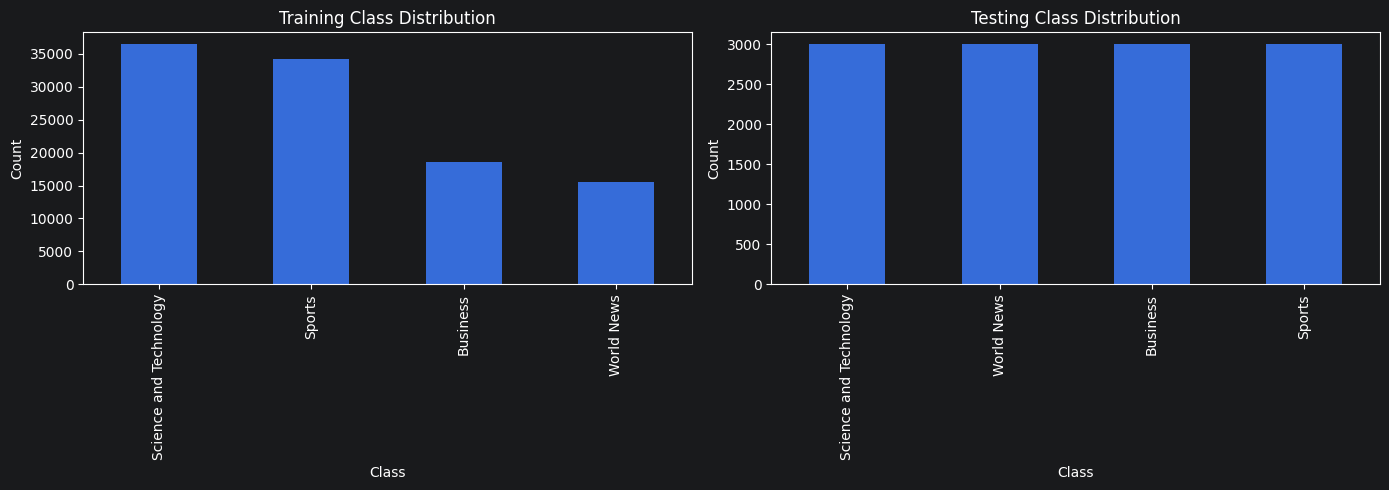

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df[TARGET_COLUMN].value_counts().plot(kind="bar", ax=axes[0], title="Training Class Distribution")
test_df[TARGET_COLUMN].value_counts().plot(kind="bar", ax=axes[1], title="Testing Class Distribution")

axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


,clean_preview_text,News Topic,char_len,word_len
0,News Headlines: Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region.,World News,165,29
1,"News Headlines: Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant software company.",Science and Technology,282,40
2,"News Headlines: Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died.",Science and Technology,181,30
3,News Headlines: U.S. Trade Deficit Swells to Record #36;55.5B (AP) AP - America's trade deficit swelled to an all-time high of #36;55.5 billion in October as imports #151; including those from China #151; surged to the loftiest levels on record. Skyrocketing crude-oil prices also contributed to ...,Business,318,50
4,"News Headlines: Nonunion firms hit ironworkers with suit Six New England steel-working firms have filed an antitrust lawsuit against one of Boston's most powerful and politically connected unions, alleging that the labor group has conspired to shut out nonunion companies from major construction ...",Business,319,47


Text length summary


,char_len,word_len
count,104763.000000,104763.000000
mean,247.072535,39.621374
std,62.420338,10.359664
min,53.000000,9.000000
25%,209.000000,33.000000
50%,244.000000,39.000000
75%,277.000000,45.000000
max,992.000000,173.000000


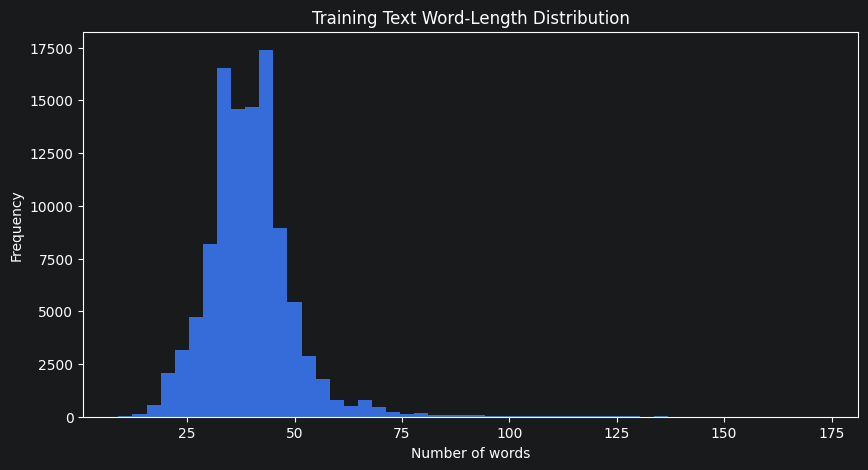

Average word count by class


,count,mean,median,min,max
News Topic,,,,,
World News,15594,40.877966,41.0,13,147
Sports,34178,39.695828,39.0,12,144
Business,18563,39.420729,39.0,9,129
Science and Technology,36428,39.115845,38.0,10,173


In [10]:

def quick_html_to_text(text):
    text = "" if pd.isna(text) else str(text)
    text = html.unescape(text)
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

eda_train = train_df.copy()
eda_train["clean_preview_text"] = eda_train[RAW_TEXT_COLUMN].apply(quick_html_to_text)
eda_train["char_len"] = eda_train["clean_preview_text"].str.len()
eda_train["word_len"] = eda_train["clean_preview_text"].str.split().apply(len)

display(eda_train[["clean_preview_text", TARGET_COLUMN, "char_len", "word_len"]].head())

print("Text length summary")
display(eda_train[["char_len", "word_len"]].describe())

plt.figure(figsize=(10, 5))
plt.hist(eda_train["word_len"], bins=50)
plt.title("Training Text Word-Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

print("Average word count by class")
display(eda_train.groupby(TARGET_COLUMN)["word_len"].agg(["count", "mean", "median", "min", "max"]).sort_values("mean", ascending=False))


In [11]:

def regex_tokens(text):
    return re.findall(r"[a-zA-Z][a-zA-Z0-9-]*|\d+(?:\.\d+)?", str(text).lower())

all_tokens = []
class_tokens = {}

for label, group in eda_train.groupby(TARGET_COLUMN):
    tokens = []
    for text in group["clean_preview_text"].head(10000):
        tokens.extend(regex_tokens(text))
    class_tokens[label] = tokens
    all_tokens.extend(tokens)

overall_counter = Counter(all_tokens)
print("Top 30 overall tokens before preprocessing")
display(pd.DataFrame(overall_counter.most_common(30), columns=["token", "count"]))

for label, tokens in class_tokens.items():
    print(f"\nTop 20 tokens for class: {label}")
    display(pd.DataFrame(Counter(tokens).most_common(20), columns=["token", "count"]))


Top 30 overall tokens before preprocessing


,token,count
0,the,68422
1,news,41122
2,headlines,40033
3,to,39904
4,a,36344
5,of,32799
6,in,32136
7,and,23220
8,s,20827
9,on,19134



Top 20 tokens for class: Business


,token,count
0,the,14951
1,news,10391
2,headlines,10006
3,to,9982
4,a,8360
5,of,7473
6,in,7463
7,s,5718
8,and,5686
9,on,5554



Top 20 tokens for class: Science and Technology


,token,count
0,the,16061
1,to,10547
2,news,10368
3,headlines,10008
4,a,9011
5,of,8814
6,and,6237
7,in,6001
8,s,4536
9,for,4310



Top 20 tokens for class: Sports


,token,count
0,the,21099
1,news,10126
2,headlines,10018
3,to,9088
4,a,8748
5,in,7989
6,of,6809
7,and,5362
8,39,4878
9,s,4761



Top 20 tokens for class: World News


,token,count
0,the,16311
1,in,10683
2,to,10287
3,news,10237
4,a,10225
5,headlines,10001
6,of,9703
7,and,5935
8,s,5812
9,on,5474


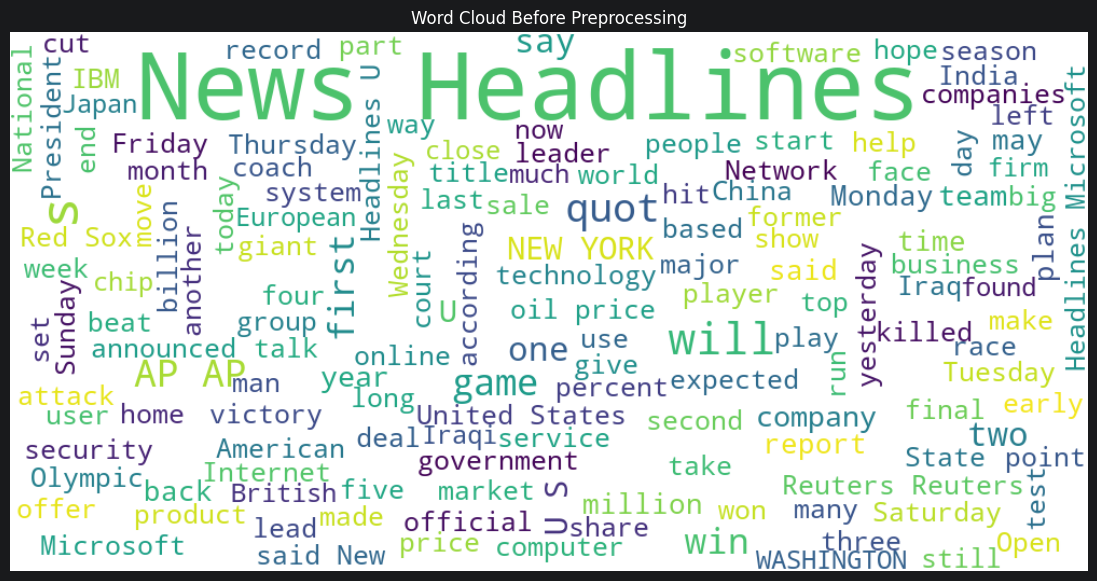

In [12]:

sample_text_for_wordcloud = " ".join(eda_train["clean_preview_text"].sample(min(8000, len(eda_train)), random_state=SEED))

wordcloud = WordCloud(width=1000, height=500, background_color="white", max_words=150).generate(sample_text_for_wordcloud)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Before Preprocessing")
plt.show()



### EDA decision for preprocessing

The raw text contains HTML tags and repeated boilerplate such as `News Headlines`. The extreme version removes aggressively and stems words. The optimum version removes HTML/boilerplate/noise but does not stem, because stemming can damage important news-category signals such as company names, sports teams, places, and technology terms.


## 3. Preprocessing: none, extreme, and optimum

In [13]:

stemmer = PorterStemmer()

STOPWORDS = set(ENGLISH_STOP_WORDS)
DOMAIN_NOISE = {
    "html", "body", "br", "b", "news", "headline", "headlines",
    "reuters", "ap", "afp", "said", "says"
}

def strip_html(text):
    text = "" if pd.isna(text) else str(text)
    text = html.unescape(text)
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    text = re.sub(r"News\s+Headlines\s*:?", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_for_project(text):
    return re.findall(r"[a-zA-Z][a-zA-Z0-9-]*|\d+(?:\.\d+)?", str(text).lower())

def preprocess_none(text):
    return "" if pd.isna(text) else str(text)

def preprocess_extreme(text):
    text = strip_html(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [
        stemmer.stem(token)
        for token in tokens
        if token not in STOPWORDS
        and token not in DOMAIN_NOISE
        and len(token) > 2
    ]
    return " ".join(tokens)

def preprocess_optimum(text):
    text = strip_html(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-z0-9\-\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = tokenize_for_project(text)
    tokens = [
        token
        for token in tokens
        if token not in DOMAIN_NOISE
        and len(token) > 1
    ]
    return " ".join(tokens)

PREPROCESSORS = {
    "none": preprocess_none,
    "extreme": preprocess_extreme,
    "optimum": preprocess_optimum
}

def cache_name_for_dataframe(df, split_name, preprocess_name):
    raw_key = f"{split_name}_{preprocess_name}_{len(df)}_{hashlib.md5(str(df.shape).encode()).hexdigest()}"
    return PREPROCESSED_DIR / f"{raw_key}.csv"

def build_or_load_preprocessed(df, split_name, preprocess_name, force=False):
    cache_path = cache_name_for_dataframe(df, split_name, preprocess_name)

    if cache_path.exists() and not force:
        loaded = pd.read_csv(cache_path)
        loaded[TEXT_COLUMN] = loaded[TEXT_COLUMN].fillna("")
        return loaded

    out = df.copy()
    out[TEXT_COLUMN] = out[RAW_TEXT_COLUMN].apply(PREPROCESSORS[preprocess_name])
    out[TEXT_COLUMN] = out[TEXT_COLUMN].fillna("")
    out.to_csv(cache_path, index=False)
    return out

preprocessed_train = {}
preprocessed_test = {}

for preprocess_name in PREPROCESSORS:
    print("Preparing:", preprocess_name)
    preprocessed_train[preprocess_name] = build_or_load_preprocessed(
        train_df, "train", preprocess_name, FORCE_REBUILD_PREPROCESSED
    )
    preprocessed_test[preprocess_name] = build_or_load_preprocessed(
        test_df, "test", preprocess_name, FORCE_REBUILD_PREPROCESSED
    )

for preprocess_name in PREPROCESSORS:
    print("\nPreprocessing:", preprocess_name)
    display(preprocessed_train[preprocess_name][[RAW_TEXT_COLUMN, TEXT_COLUMN, TARGET_COLUMN]].head(3))


Preparing: none
Preparing: extreme
Preparing: optimum

Preprocessing: none


,News Headline,text,News Topic
0,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,World News
1,"<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...","<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...",Science and Technology
2,"<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>","<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>",Science and Technology



Preprocessing: extreme


,News Headline,text,News Topic
0,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,huge boost darfur aid effort world food programm start airlift ton food day sudan troubl darfur region,World News
1,"<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...",microsoft revis anti spam standard microsoft corp monday revis propos weed spam mail win skeptic internet engin reluct adopt technolog own domin softwar compani,Science and Technology
2,"<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>",gordon cooper astronaut ventura calif gordon cooper origin mercuri astronaut pioneer human space explor die,Science and Technology



Preprocessing: optimum


,News Headline,text,News Topic
0,<html> <body> News Headlines:\r\n <br> <b> Huge boost to Darfur aid effort The World Food Programme is starting to airlift almost 100 more tons of food a day to Sudan's troubled Darfur region. </b> \r\n <br> <br>,huge boost to darfur aid effort the world food programme is starting to airlift almost 100 more tons of food day to sudan troubled darfur region,World News
1,"<html> <body> News Headlines:\r\n <br> <b> Microsoft Revises Anti-Spam Standard (Reuters) Reuters - Microsoft Corp. on Monday\said it had revised its proposal to weed out ""spam"" e-mail to\win over skeptical Internet engineers who have been reluctant\to adopt technology owned by the dominant sof...",microsoft revises anti-spam standard microsoft corp on monday it had revised its proposal to weed out spam e-mail to win over skeptical internet engineers who have been reluctant to adopt technology owned by the dominant software company,Science and Technology
2,"<html> <body> News Headlines:\r\n <br> <b> Gordon Cooper, 1 of 1st astronauts VENTURA, Calif. - Gordon Cooper, who as one of the original Mercury astronauts was a pioneer in human space exploration, has died. </b> \r\n <br> <br>",gordon cooper of st astronauts ventura calif gordon cooper who as one of the original mercury astronauts was pioneer in human space exploration has died,Science and Technology



Length summary for none


count    104763.000000
mean         46.677701
std          10.393169
min          17.000000
25%          40.000000
50%          46.000000
75%          52.000000
max         180.000000
Name: word_len, dtype: float64

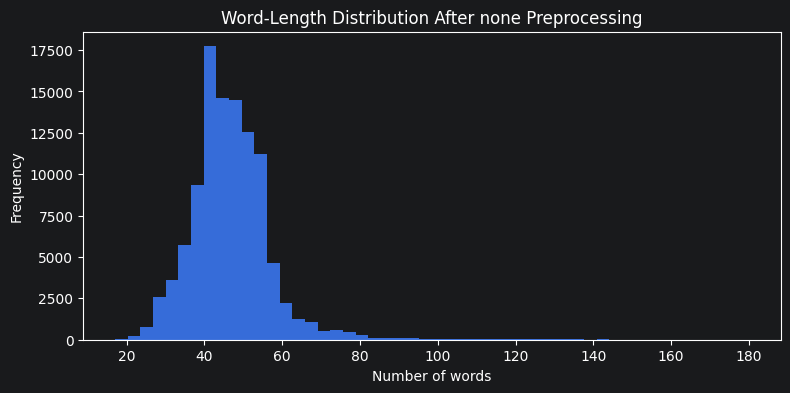


Length summary for extreme


count    104763.000000
mean         22.477401
std           5.948184
min           5.000000
25%          19.000000
50%          22.000000
75%          26.000000
max          86.000000
Name: word_len, dtype: float64

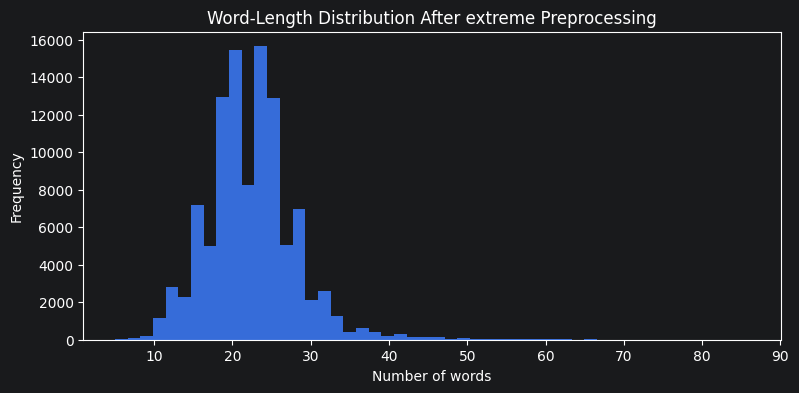


Length summary for optimum


count    104763.000000
mean         35.855483
std           9.910233
min           6.000000
25%          30.000000
50%          35.000000
75%          41.000000
max         161.000000
Name: word_len, dtype: float64

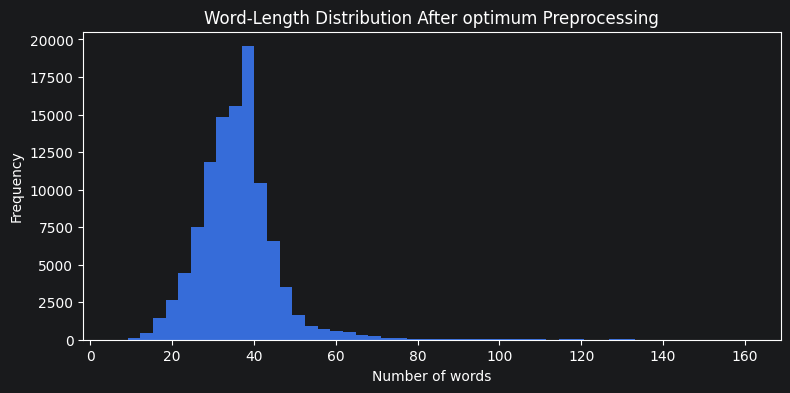

In [14]:

for preprocess_name in PREPROCESSORS:
    temp = preprocessed_train[preprocess_name].copy()
    temp["word_len"] = temp[TEXT_COLUMN].str.split().apply(len)

    print(f"\nLength summary for {preprocess_name}")
    display(temp["word_len"].describe())

    plt.figure(figsize=(9, 4))
    plt.hist(temp["word_len"], bins=50)
    plt.title(f"Word-Length Distribution After {preprocess_name} Preprocessing")
    plt.xlabel("Number of words")
    plt.ylabel("Frequency")
    plt.show()


## 4. Label encoding and validation split

In [15]:

label_encoder = LabelEncoder()
y_train_full = label_encoder.fit_transform(train_df[TARGET_COLUMN])
y_test = label_encoder.transform(test_df[TARGET_COLUMN])
class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("Classes:", class_names)

split_cache_path = SPLIT_DIR / "train_validation_indices.pkl"

if split_cache_path.exists() and not FORCE_NEW_SPLIT:
    with open(split_cache_path, "rb") as f:
        split_data = pickle.load(f)
    train_idx = split_data["train_idx"]
    val_idx = split_data["val_idx"]
else:
    train_idx, val_idx = train_test_split(
        np.arange(len(train_df)),
        test_size=0.15,
        random_state=SEED,
        stratify=y_train_full
    )
    with open(split_cache_path, "wb") as f:
        pickle.dump({"train_idx": train_idx, "val_idx": val_idx}, f)

y_train_core = y_train_full[train_idx]
y_val = y_train_full[val_idx]

print("Training rows used for model fitting:", len(train_idx))
print("Validation rows used for tuning:", len(val_idx))
print("Final test rows:", len(y_test))

print("\nValidation class distribution")
display(pd.Series(y_val).map(dict(enumerate(class_names))).value_counts().to_frame("count"))


Classes: ['Business', 'Science and Technology', 'Sports', 'World News']
Training rows used for model fitting: 89048
Validation rows used for tuning: 15715
Final test rows: 12000

Validation class distribution


,count
Science and Technology,5464
Sports,5127
Business,2785
World News,2339


## 5. Shared evaluation and logging functions

In [16]:

EXPERIMENT_LOG = []
BEST_ARTIFACTS = {}

def now_string():
    return time.strftime("%Y-%m-%d %H:%M:%S")

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro")
    }

def print_evaluation(title, y_true, y_pred, show_matrix=True):
    metrics = compute_metrics(y_true, y_pred)
    print("=" * 90)
    print(title)
    print("Accuracy:", round(metrics["accuracy"], 5))
    print("Macro F1:", round(metrics["macro_f1"], 5))
    print("\nClassification Report")
    print(classification_report(y_true, y_pred, target_names=class_names))

    if show_matrix:
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        fig, ax = plt.subplots(figsize=(7, 6))
        disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
        plt.title(title)
        plt.tight_layout()
        plt.show()

    return metrics

def add_experiment_log(
    preprocess_name,
    representation,
    model_name,
    split_name,
    y_true,
    y_pred,
    params,
    train_seconds=None
):
    metrics = compute_metrics(y_true, y_pred)
    row = {
        "time": now_string(),
        "preprocessing": preprocess_name,
        "representation": representation,
        "model": model_name,
        "split": split_name,
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "train_seconds": train_seconds,
        "params": json.dumps(params, default=str)
    }
    EXPERIMENT_LOG.append(row)
    return row

def show_experiment_log(split_name=None):
    df = pd.DataFrame(EXPERIMENT_LOG)
    if df.empty:
        print("No experiments logged yet.")
        return df

    if split_name is not None:
        df = df[df["split"] == split_name]

    df = df.sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
    display(df)
    return df

def save_log():
    log_df = pd.DataFrame(EXPERIMENT_LOG)
    log_path = LOG_DIR / "experiment_log_pytorch.csv"
    log_df.to_csv(log_path, index=False)
    print("Saved log to:", log_path)
    return log_df

def clear_torch_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def get_class_weights(y_values):
    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(num_classes),
        y=y_values
    )
    return torch.tensor(weights, dtype=torch.float32, device=device)


## 6. TF-IDF + Machine Learning model with manual tuning

In [17]:

TFIDF_ML_CONFIGS = {
    "none": [
        {"max_features": 30000, "ngram_range": (1, 2), "min_df": 2, "max_df": 0.98, "C": 1.0},
        {"max_features": 50000, "ngram_range": (1, 2), "min_df": 2, "max_df": 0.98, "C": 2.0}
    ],
    "extreme": [
        {"max_features": 30000, "ngram_range": (1, 2), "min_df": 2, "max_df": 0.95, "C": 1.0},
        {"max_features": 50000, "ngram_range": (1, 2), "min_df": 2, "max_df": 0.98, "C": 2.0}
    ],
    "optimum": [
        {"max_features": 50000, "ngram_range": (1, 2), "min_df": 2, "max_df": 0.98, "C": 2.0},
        {"max_features": 60000, "ngram_range": (1, 2), "min_df": 2, "max_df": 0.98, "C": 4.0},
        {"max_features": 80000, "ngram_range": (1, 2), "min_df": 2, "max_df": 0.99, "C": 4.0},
        {"max_features": 70000, "ngram_range": (1, 3), "min_df": 2, "max_df": 0.99, "C": 3.0}
    ]
}

def train_tfidf_logreg_for_config(preprocess_name, config):
    train_texts = preprocessed_train[preprocess_name].iloc[train_idx][TEXT_COLUMN].fillna("").tolist()
    val_texts = preprocessed_train[preprocess_name].iloc[val_idx][TEXT_COLUMN].fillna("").tolist()

    vectorizer = TfidfVectorizer(
        max_features=config["max_features"],
        ngram_range=config["ngram_range"],
        min_df=config["min_df"],
        max_df=config["max_df"],
        sublinear_tf=True,
        strip_accents="unicode"
    )

    start = time.time()
    X_train_tfidf = vectorizer.fit_transform(train_texts)
    X_val_tfidf = vectorizer.transform(val_texts)

    model = LogisticRegression(
        C=config["C"],
        solver="saga",
        penalty="l2",
        max_iter=1200,
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED
    )

    model.fit(X_train_tfidf, y_train_core)
    val_pred = model.predict(X_val_tfidf)
    train_seconds = time.time() - start

    row = add_experiment_log(
        preprocess_name=preprocess_name,
        representation="TF-IDF",
        model_name="LogisticRegression",
        split_name="validation",
        y_true=y_val,
        y_pred=val_pred,
        params=config,
        train_seconds=train_seconds
    )

    print(
        f"{preprocess_name} | TF-IDF + LogisticRegression | "
        f"F1={row['macro_f1']:.5f} | Acc={row['accuracy']:.5f} | "
        f"seconds={train_seconds:.1f} | {config}"
    )

    return row, vectorizer, model

if RUN_TFIDF_ML:
    for preprocess_name, config_list in TFIDF_ML_CONFIGS.items():
        best_row = None
        best_vectorizer = None
        best_model = None
        best_config = None

        for config in config_list:
            row, vectorizer, model = train_tfidf_logreg_for_config(preprocess_name, config)
            if best_row is None or row["macro_f1"] > best_row["macro_f1"]:
                best_row = row
                best_vectorizer = vectorizer
                best_model = model
                best_config = config

        BEST_ARTIFACTS[(preprocess_name, "TF-IDF", "LogisticRegression")] = {
            "kind": "tfidf_ml",
            "preprocessing": preprocess_name,
            "vectorizer": best_vectorizer,
            "model": best_model,
            "params": best_config,
            "validation_row": best_row
        }

show_experiment_log("validation")


none | TF-IDF + LogisticRegression | F1=0.92161 | Acc=0.93280 | seconds=24.6 | {'max_features': 30000, 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.98, 'C': 1.0}
none | TF-IDF + LogisticRegression | F1=0.93143 | Acc=0.94209 | seconds=23.4 | {'max_features': 50000, 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.98, 'C': 2.0}
extreme | TF-IDF + LogisticRegression | F1=0.91886 | Acc=0.93045 | seconds=13.5 | {'max_features': 30000, 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.95, 'C': 1.0}
extreme | TF-IDF + LogisticRegression | F1=0.92607 | Acc=0.93751 | seconds=15.7 | {'max_features': 50000, 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.98, 'C': 2.0}
optimum | TF-IDF + LogisticRegression | F1=0.92652 | Acc=0.93802 | seconds=21.5 | {'max_features': 50000, 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.98, 'C': 2.0}
optimum | TF-IDF + LogisticRegression | F1=0.93149 | Acc=0.94286 | seconds=24.5 | {'max_features': 60000, 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.98, 'C': 4.0

,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-24 20:04:59,optimum,TF-IDF,LogisticRegression,validation,0.943875,0.932534,24.100349,"{""max_features"": 80000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99, ""C"": 4.0}"
1,2026-04-24 20:04:35,optimum,TF-IDF,LogisticRegression,validation,0.942857,0.931485,24.465277,"{""max_features"": 60000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 4.0}"
2,2026-04-24 20:03:19,none,TF-IDF,LogisticRegression,validation,0.942094,0.931430,23.372463,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
3,2026-04-24 20:05:34,optimum,TF-IDF,LogisticRegression,validation,0.941839,0.930339,35.217938,"{""max_features"": 70000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.99, ""C"": 3.0}"
4,2026-04-24 20:04:10,optimum,TF-IDF,LogisticRegression,validation,0.938021,0.926522,21.544559,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
5,2026-04-24 20:03:48,extreme,TF-IDF,LogisticRegression,validation,0.937512,0.926068,15.677610,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
6,2026-04-24 20:02:56,none,TF-IDF,LogisticRegression,validation,0.932803,0.921611,24.646307,"{""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 1.0}"
7,2026-04-24 20:03:33,extreme,TF-IDF,LogisticRegression,validation,0.930449,0.918864,13.545148,"{""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.95, ""C"": 1.0}"


,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-24 20:04:59,optimum,TF-IDF,LogisticRegression,validation,0.943875,0.932534,24.100349,"{""max_features"": 80000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99, ""C"": 4.0}"
1,2026-04-24 20:04:35,optimum,TF-IDF,LogisticRegression,validation,0.942857,0.931485,24.465277,"{""max_features"": 60000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 4.0}"
2,2026-04-24 20:03:19,none,TF-IDF,LogisticRegression,validation,0.942094,0.931430,23.372463,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
3,2026-04-24 20:05:34,optimum,TF-IDF,LogisticRegression,validation,0.941839,0.930339,35.217938,"{""max_features"": 70000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.99, ""C"": 3.0}"
4,2026-04-24 20:04:10,optimum,TF-IDF,LogisticRegression,validation,0.938021,0.926522,21.544559,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
5,2026-04-24 20:03:48,extreme,TF-IDF,LogisticRegression,validation,0.937512,0.926068,15.677610,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
6,2026-04-24 20:02:56,none,TF-IDF,LogisticRegression,validation,0.932803,0.921611,24.646307,"{""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 1.0}"
7,2026-04-24 20:03:33,extreme,TF-IDF,LogisticRegression,validation,0.930449,0.918864,13.545148,"{""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.95, ""C"": 1.0}"


## 7. TF-IDF + Deep Neural Network in PyTorch

In [18]:

class TfidfDNN(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout, num_classes):
        super().__init__()
        layers = []
        current_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

def predict_tfidf_dnn(model, X_sparse, batch_size=512):
    model.eval()
    preds = []

    with torch.no_grad():
        for start_idx in range(0, X_sparse.shape[0], batch_size):
            end_idx = min(start_idx + batch_size, X_sparse.shape[0])
            xb = torch.tensor(
                X_sparse[start_idx:end_idx].toarray(),
                dtype=torch.float32,
                device=device
            )
            logits = model(xb)
            batch_pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
            preds.extend(batch_pred)

    return np.array(preds)

def train_tfidf_dnn_model(X_train_sparse, y_train_values, X_val_sparse, y_val_values, config, input_dim, checkpoint_path):
    model = TfidfDNN(
        input_dim=input_dim,
        hidden_layers=config["hidden_layers"],
        dropout=config["dropout"],
        num_classes=num_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=get_class_weights(y_train_values))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    best_f1 = -1
    best_state = None
    bad_epochs = 0
    history = []

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        permutation = np.random.permutation(X_train_sparse.shape[0])
        total_loss = 0.0
        total_seen = 0

        for start_idx in range(0, len(permutation), config["batch_size"]):
            batch_idx = permutation[start_idx:start_idx + config["batch_size"]]

            xb = torch.tensor(
                X_train_sparse[batch_idx].toarray(),
                dtype=torch.float32,
                device=device
            )
            yb = torch.tensor(
                y_train_values[batch_idx],
                dtype=torch.long,
                device=device
            )

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            total_loss += loss.item() * len(batch_idx)
            total_seen += len(batch_idx)

        val_pred = predict_tfidf_dnn(model, X_val_sparse, batch_size=config["batch_size"])
        val_metrics = compute_metrics(y_val_values, val_pred)
        avg_loss = total_loss / max(total_seen, 1)

        history.append({
            "epoch": epoch,
            "train_loss": avg_loss,
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"]
        })

        print(
            f"Epoch {epoch:02d} | loss={avg_loss:.5f} | "
            f"val_acc={val_metrics['accuracy']:.5f} | val_f1={val_metrics['macro_f1']:.5f}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_state, checkpoint_path)
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= config["patience"]:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

TFIDF_DNN_CONFIGS = {
    "none": [
        {
            "tfidf": {"max_features": 30000, "ngram_range": (1, 2), "min_df": 2, "max_df": 0.98},
            "hidden_layers": [512, 256, 128, 64],
            "dropout": 0.35,
            "lr": 0.001,
            "weight_decay": 0.0001,
            "batch_size": 256,
            "epochs": 8,
            "patience": 2
        }
    ],
    "extreme": [
        {
            "tfidf": {"max_features": 30000, "ngram_range": (1, 2), "min_df": 2, "max_df": 0.98},
            "hidden_layers": [512, 256, 128, 64],
            "dropout": 0.35,
            "lr": 0.001,
            "weight_decay": 0.0001,
            "batch_size": 256,
            "epochs": 8,
            "patience": 2
        }
    ],
    "optimum": [
        {
            "tfidf": {"max_features": 50000, "ngram_range": (1, 2), "min_df": 2, "max_df": 0.98},
            "hidden_layers": [768, 384, 192, 96],
            "dropout": 0.35,
            "lr": 0.001,
            "weight_decay": 0.0001,
            "batch_size": 256,
            "epochs": 10,
            "patience": 3
        },
        {
            "tfidf": {"max_features": 60000, "ngram_range": (1, 2), "min_df": 2, "max_df": 0.99},
            "hidden_layers": [1024, 512, 256, 128],
            "dropout": 0.40,
            "lr": 0.0007,
            "weight_decay": 0.0002,
            "batch_size": 192,
            "epochs": 10,
            "patience": 3
        }
    ]
}


In [19]:

def run_tfidf_dnn_experiment(preprocess_name, config, run_id):
    train_texts = preprocessed_train[preprocess_name].iloc[train_idx][TEXT_COLUMN].fillna("").tolist()
    val_texts = preprocessed_train[preprocess_name].iloc[val_idx][TEXT_COLUMN].fillna("").tolist()

    tfidf_config = config["tfidf"]
    vectorizer = TfidfVectorizer(
        max_features=tfidf_config["max_features"],
        ngram_range=tfidf_config["ngram_range"],
        min_df=tfidf_config["min_df"],
        max_df=tfidf_config["max_df"],
        sublinear_tf=True,
        strip_accents="unicode"
    )

    X_train_tfidf = vectorizer.fit_transform(train_texts)
    X_val_tfidf = vectorizer.transform(val_texts)

    checkpoint_path = CHECKPOINT_DIR / f"tfidf_dnn_{preprocess_name}_{run_id}.pt"

    start = time.time()
    model, history = train_tfidf_dnn_model(
        X_train_sparse=X_train_tfidf,
        y_train_values=y_train_core,
        X_val_sparse=X_val_tfidf,
        y_val_values=y_val,
        config=config,
        input_dim=X_train_tfidf.shape[1],
        checkpoint_path=checkpoint_path
    )
    train_seconds = time.time() - start

    history_path = HISTORY_DIR / f"tfidf_dnn_{preprocess_name}_{run_id}.csv"
    history.to_csv(history_path, index=False)

    val_pred = predict_tfidf_dnn(model, X_val_tfidf, batch_size=config["batch_size"])

    row = add_experiment_log(
        preprocess_name=preprocess_name,
        representation="TF-IDF",
        model_name="DeepNeuralNetwork",
        split_name="validation",
        y_true=y_val,
        y_pred=val_pred,
        params=config,
        train_seconds=train_seconds
    )

    print(
        f"{preprocess_name} | TF-IDF + DNN | "
        f"F1={row['macro_f1']:.5f} | Acc={row['accuracy']:.5f} | "
        f"seconds={train_seconds:.1f}"
    )

    return row, vectorizer, model, history

if RUN_TFIDF_DNN:
    for preprocess_name, config_list in TFIDF_DNN_CONFIGS.items():
        best_row = None
        best_vectorizer = None
        best_model = None
        best_config = None
        best_history = None

        for run_id, config in enumerate(config_list, start=1):
            print("\n" + "=" * 90)
            print(f"Running TF-IDF DNN: {preprocess_name}, config {run_id}/{len(config_list)}")
            row, vectorizer, model, history = run_tfidf_dnn_experiment(preprocess_name, config, run_id)

            if best_row is None or row["macro_f1"] > best_row["macro_f1"]:
                best_row = row
                best_vectorizer = vectorizer
                best_model = model
                best_config = config
                best_history = history

            clear_torch_memory()

        BEST_ARTIFACTS[(preprocess_name, "TF-IDF", "DeepNeuralNetwork")] = {
            "kind": "tfidf_dnn",
            "preprocessing": preprocess_name,
            "vectorizer": best_vectorizer,
            "model": best_model,
            "params": best_config,
            "history": best_history,
            "validation_row": best_row
        }

show_experiment_log("validation")



Running TF-IDF DNN: none, config 1/1
Epoch 01 | loss=0.37015 | val_acc=0.94222 | val_f1=0.93094
Epoch 02 | loss=0.13841 | val_acc=0.94438 | val_f1=0.93276
Epoch 03 | loss=0.06908 | val_acc=0.94146 | val_f1=0.92933
Epoch 04 | loss=0.04197 | val_acc=0.94178 | val_f1=0.92962
Early stopping triggered.
none | TF-IDF + DNN | F1=0.93276 | Acc=0.94438 | seconds=103.0

Running TF-IDF DNN: extreme, config 1/1
Epoch 01 | loss=0.36970 | val_acc=0.93637 | val_f1=0.92525
Epoch 02 | loss=0.16412 | val_acc=0.94152 | val_f1=0.92885
Epoch 03 | loss=0.08949 | val_acc=0.93751 | val_f1=0.92468
Epoch 04 | loss=0.05690 | val_acc=0.93605 | val_f1=0.92279
Early stopping triggered.
extreme | TF-IDF + DNN | F1=0.92885 | Acc=0.94152 | seconds=89.2

Running TF-IDF DNN: optimum, config 1/2
Epoch 01 | loss=0.34311 | val_acc=0.93821 | val_f1=0.92720
Epoch 02 | loss=0.11747 | val_acc=0.94095 | val_f1=0.92809
Epoch 03 | loss=0.04543 | val_acc=0.94216 | val_f1=0.92941
Epoch 04 | loss=0.02877 | val_acc=0.94165 | val_f1=

,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-24 20:07:38,none,TF-IDF,DeepNeuralNetwork,validation,0.944384,0.932757,102.959434,"{""tfidf"": {""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""hidden_layers"": [512, 256, 128, 64], ""dropout"": 0.35, ""lr"": 0.001, ""weight_decay"": 0.0001, ""batch_size"": 256, ""epochs"": 8, ""patience"": 2}"
1,2026-04-24 20:04:59,optimum,TF-IDF,LogisticRegression,validation,0.943875,0.932534,24.100349,"{""max_features"": 80000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99, ""C"": 4.0}"
2,2026-04-24 20:04:35,optimum,TF-IDF,LogisticRegression,validation,0.942857,0.931485,24.465277,"{""max_features"": 60000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 4.0}"
3,2026-04-24 20:03:19,none,TF-IDF,LogisticRegression,validation,0.942094,0.931430,23.372463,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
4,2026-04-24 20:16:51,optimum,TF-IDF,DeepNeuralNetwork,validation,0.942284,0.931369,200.913574,"{""tfidf"": {""max_features"": 60000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99}, ""hidden_layers"": [1024, 512, 256, 128], ""dropout"": 0.4, ""lr"": 0.0007, ""weight_decay"": 0.0002, ""batch_size"": 192, ""epochs"": 10, ""patience"": 3}"
5,2026-04-24 20:05:34,optimum,TF-IDF,LogisticRegression,validation,0.941839,0.930339,35.217938,"{""max_features"": 70000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.99, ""C"": 3.0}"
6,2026-04-24 20:13:07,optimum,TF-IDF,DeepNeuralNetwork,validation,0.942157,0.929406,206.423529,"{""tfidf"": {""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""hidden_layers"": [768, 384, 192, 96], ""dropout"": 0.35, ""lr"": 0.001, ""weight_decay"": 0.0001, ""batch_size"": 256, ""epochs"": 10, ""patience"": 3}"
7,2026-04-24 20:09:20,extreme,TF-IDF,DeepNeuralNetwork,validation,0.941521,0.928852,89.229115,"{""tfidf"": {""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""hidden_layers"": [512, 256, 128, 64], ""dropout"": 0.35, ""lr"": 0.001, ""weight_decay"": 0.0001, ""batch_size"": 256, ""epochs"": 8, ""patience"": 2}"
8,2026-04-24 20:04:10,optimum,TF-IDF,LogisticRegression,validation,0.938021,0.926522,21.544559,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
9,2026-04-24 20:03:48,extreme,TF-IDF,LogisticRegression,validation,0.937512,0.926068,15.677610,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"


,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-24 20:07:38,none,TF-IDF,DeepNeuralNetwork,validation,0.944384,0.932757,102.959434,"{""tfidf"": {""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""hidden_layers"": [512, 256, 128, 64], ""dropout"": 0.35, ""lr"": 0.001, ""weight_decay"": 0.0001, ""batch_size"": 256, ""epochs"": 8, ""patience"": 2}"
1,2026-04-24 20:04:59,optimum,TF-IDF,LogisticRegression,validation,0.943875,0.932534,24.100349,"{""max_features"": 80000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99, ""C"": 4.0}"
2,2026-04-24 20:04:35,optimum,TF-IDF,LogisticRegression,validation,0.942857,0.931485,24.465277,"{""max_features"": 60000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 4.0}"
3,2026-04-24 20:03:19,none,TF-IDF,LogisticRegression,validation,0.942094,0.931430,23.372463,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
4,2026-04-24 20:16:51,optimum,TF-IDF,DeepNeuralNetwork,validation,0.942284,0.931369,200.913574,"{""tfidf"": {""max_features"": 60000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99}, ""hidden_layers"": [1024, 512, 256, 128], ""dropout"": 0.4, ""lr"": 0.0007, ""weight_decay"": 0.0002, ""batch_size"": 192, ""epochs"": 10, ""patience"": 3}"
5,2026-04-24 20:05:34,optimum,TF-IDF,LogisticRegression,validation,0.941839,0.930339,35.217938,"{""max_features"": 70000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.99, ""C"": 3.0}"
6,2026-04-24 20:13:07,optimum,TF-IDF,DeepNeuralNetwork,validation,0.942157,0.929406,206.423529,"{""tfidf"": {""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""hidden_layers"": [768, 384, 192, 96], ""dropout"": 0.35, ""lr"": 0.001, ""weight_decay"": 0.0001, ""batch_size"": 256, ""epochs"": 10, ""patience"": 3}"
7,2026-04-24 20:09:20,extreme,TF-IDF,DeepNeuralNetwork,validation,0.941521,0.928852,89.229115,"{""tfidf"": {""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""hidden_layers"": [512, 256, 128, 64], ""dropout"": 0.35, ""lr"": 0.001, ""weight_decay"": 0.0001, ""batch_size"": 256, ""epochs"": 8, ""patience"": 2}"
8,2026-04-24 20:04:10,optimum,TF-IDF,LogisticRegression,validation,0.938021,0.926522,21.544559,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
9,2026-04-24 20:03:48,extreme,TF-IDF,LogisticRegression,validation,0.937512,0.926068,15.677610,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"


## 8. Skip-gram word representation helpers

In [20]:

def tokenize_preprocessed_text(text):
    tokens = tokenize_for_project(text)
    return [token for token in tokens if len(token) > 0]

def get_tokens_for_split(preprocess_name, indices=None, split="train"):
    if split == "train":
        source_df = preprocessed_train[preprocess_name]
    elif split == "test":
        source_df = preprocessed_test[preprocess_name]
    else:
        raise ValueError("split must be train or test")

    if indices is not None:
        source_df = source_df.iloc[indices]

    return [tokenize_preprocessed_text(text) for text in source_df[TEXT_COLUMN].fillna("").tolist()]

def train_word2vec_compatible(sentences, vector_size, window, min_count, epochs, workers=4):
    try:
        model = Word2Vec(
            sentences=sentences,
            vector_size=vector_size,
            window=window,
            min_count=min_count,
            workers=workers,
            sg=1,
            seed=SEED,
            epochs=epochs
        )
    except TypeError:
        model = Word2Vec(
            sentences,
            size=vector_size,
            window=window,
            min_count=min_count,
            workers=workers,
            sg=1,
            seed=SEED,
            iter=epochs
        )

    return model

def w2v_vector_size(model):
    if hasattr(model, "vector_size"):
        return model.vector_size
    if hasattr(model, "layer1_size"):
        return model.layer1_size
    if hasattr(model, "wv") and hasattr(model.wv, "vector_size"):
        return model.wv.vector_size
    first_word = list(w2v_words(model))[0]
    return len(w2v_get_vector(model, first_word))

def w2v_words(model):
    if hasattr(model, "wv"):
        if hasattr(model.wv, "key_to_index"):
            return list(model.wv.key_to_index.keys())
        if hasattr(model.wv, "index_to_key"):
            return list(model.wv.index_to_key)
        if hasattr(model.wv, "index2word"):
            return list(model.wv.index2word)

    if hasattr(model, "index2word"):
        return list(model.index2word)

    return []

def w2v_get_vector(model, word):
    if hasattr(model, "wv"):
        return model.wv[word]
    return model[word]

def build_vocab_from_token_lists(token_lists, max_words, min_freq=1, allowed_words=None):
    counter = Counter()
    for tokens in token_lists:
        counter.update(tokens)

    vocab = {"<PAD>": 0, "<UNK>": 1}
    allowed_set = set(allowed_words) if allowed_words is not None else None

    for word, freq in counter.most_common():
        if freq < min_freq:
            continue
        if allowed_set is not None and word not in allowed_set:
            continue
        if word in vocab:
            continue
        vocab[word] = len(vocab)
        if len(vocab) >= max_words:
            break

    return vocab

def token_lists_to_padded_sequences(token_lists, vocab, max_len):
    sequences = np.zeros((len(token_lists), max_len), dtype=np.int64)

    for i, tokens in enumerate(token_lists):
        ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens[:max_len]]
        if len(ids) > 0:
            sequences[i, :len(ids)] = ids

    return sequences

def build_embedding_matrix(w2v_model, vocab):
    dim = w2v_vector_size(w2v_model)
    rng = np.random.default_rng(SEED)
    embedding_matrix = rng.normal(0, 0.05, size=(len(vocab), dim)).astype(np.float32)
    embedding_matrix[vocab["<PAD>"]] = np.zeros(dim, dtype=np.float32)

    available = set(w2v_words(w2v_model))

    for word, idx in vocab.items():
        if word in available:
            embedding_matrix[idx] = np.asarray(w2v_get_vector(w2v_model, word), dtype=np.float32)

    return embedding_matrix

class SequenceTextDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.sequences[index], self.labels[index]


## 9. PyTorch sequence models: SimpleRNN, GRU, LSTM, and bidirectional versions

In [21]:

class SkipgramRNNClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        rnn_type,
        hidden_size,
        num_layers,
        dropout,
        bidirectional,
        dense_size,
        num_classes
    ):
        super().__init__()

        embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor,
            freeze=False,
            padding_idx=0
        )

        embedding_dim = embedding_matrix.shape[1]
        rnn_dropout = dropout if num_layers > 1 else 0.0

        if rnn_type == "rnn":
            self.rnn = nn.RNN(
                input_size=embedding_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional
            )
        elif rnn_type == "gru":
            self.rnn = nn.GRU(
                input_size=embedding_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional
            )
        elif rnn_type == "lstm":
            self.rnn = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional
            )
        else:
            raise ValueError("rnn_type must be rnn, gru, or lstm")

        output_size = hidden_size * 2 if bidirectional else hidden_size

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(output_size, dense_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dense_size, num_classes)
        )

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)

        if isinstance(hidden, tuple):
            hidden = hidden[0]

        if self.rnn.bidirectional:
            features = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            features = hidden[-1]

        features = self.dropout(features)
        return self.classifier(features)

def predict_sequence_model(model, data_loader):
    model.eval()
    preds = []
    true_values = []

    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            logits = model(xb)
            batch_pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
            preds.extend(batch_pred)
            true_values.extend(yb.numpy())

    return np.array(true_values), np.array(preds)

def train_sequence_model(model, train_loader, val_loader, y_train_values, config, checkpoint_path):
    criterion = nn.CrossEntropyLoss(weight=get_class_weights(y_train_values))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    best_f1 = -1
    best_state = None
    bad_epochs = 0
    history = []

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        total_loss = 0.0
        total_seen = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_seen += xb.size(0)

        y_true_val, y_pred_val = predict_sequence_model(model, val_loader)
        val_metrics = compute_metrics(y_true_val, y_pred_val)
        avg_loss = total_loss / max(total_seen, 1)

        history.append({
            "epoch": epoch,
            "train_loss": avg_loss,
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"]
        })

        print(
            f"Epoch {epoch:02d} | loss={avg_loss:.5f} | "
            f"val_acc={val_metrics['accuracy']:.5f} | val_f1={val_metrics['macro_f1']:.5f}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_state, checkpoint_path)
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= config["patience"]:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

SEQUENCE_MODEL_DEFINITIONS = [
    {"model_name": "SimpleRNN", "rnn_type": "rnn", "bidirectional": False},
    {"model_name": "GRU", "rnn_type": "gru", "bidirectional": False},
    {"model_name": "LSTM", "rnn_type": "lstm", "bidirectional": False},
    {"model_name": "BidirectionalSimpleRNN", "rnn_type": "rnn", "bidirectional": True},
    {"model_name": "BidirectionalGRU", "rnn_type": "gru", "bidirectional": True},
    {"model_name": "BidirectionalLSTM", "rnn_type": "lstm", "bidirectional": True}
]

BASE_SEQUENCE_CONFIG = {
    "word2vec_vector_size": 100,
    "word2vec_window": 5,
    "word2vec_min_count": 2,
    "word2vec_epochs": 8,
    "max_words": 35000,
    "max_len": 60,
    "hidden_size": 128,
    "num_layers": 1,
    "dropout": 0.35,
    "dense_size": 96,
    "batch_size": 256,
    "lr": 0.001,
    "weight_decay": 0.0001,
    "epochs": 8,
    "patience": 2
}

OPTIMUM_SEQUENCE_CONFIGS = [
    {
        **BASE_SEQUENCE_CONFIG,
        "max_words": 45000,
        "max_len": 70,
        "hidden_size": 128,
        "dropout": 0.35,
        "dense_size": 128,
        "lr": 0.001,
        "epochs": 10,
        "patience": 3
    },
    {
        **BASE_SEQUENCE_CONFIG,
        "word2vec_vector_size": 150,
        "word2vec_window": 7,
        "max_words": 50000,
        "max_len": 80,
        "hidden_size": 160,
        "dropout": 0.40,
        "dense_size": 128,
        "lr": 0.0007,
        "epochs": 10,
        "patience": 3
    }
]

SEQUENCE_CONFIGS_BY_PREPROCESSING = {
    "none": [BASE_SEQUENCE_CONFIG],
    "extreme": [BASE_SEQUENCE_CONFIG],
    "optimum": OPTIMUM_SEQUENCE_CONFIGS
}


## 10. Run Skip-gram + all required PyTorch sequence models

In [22]:

def prepare_skipgram_data(preprocess_name, config, run_id):
    train_tokens_all = get_tokens_for_split(preprocess_name, indices=train_idx, split="train")
    val_tokens = get_tokens_for_split(preprocess_name, indices=val_idx, split="train")

    w2v_cache_path = SKIPGRAM_DIR / (
        f"word2vec_{preprocess_name}_{run_id}_"
        f"dim{config['word2vec_vector_size']}_win{config['word2vec_window']}.model"
    )

    if w2v_cache_path.exists() and not FORCE_REBUILD_SKIPGRAM:
        print("Loading cached Word2Vec:", w2v_cache_path)
        w2v_model = Word2Vec.load(str(w2v_cache_path))
    else:
        print("Training Word2Vec skip-gram model...")
        w2v_model = train_word2vec_compatible(
            sentences=train_tokens_all,
            vector_size=config["word2vec_vector_size"],
            window=config["word2vec_window"],
            min_count=config["word2vec_min_count"],
            epochs=config["word2vec_epochs"],
            workers=max(1, os.cpu_count() - 1 if os.cpu_count() else 1)
        )
        w2v_model.save(str(w2v_cache_path))

    vocab = build_vocab_from_token_lists(
        token_lists=train_tokens_all,
        max_words=config["max_words"],
        min_freq=1,
        allowed_words=w2v_words(w2v_model)
    )

    embedding_matrix = build_embedding_matrix(w2v_model, vocab)

    X_train_seq = token_lists_to_padded_sequences(train_tokens_all, vocab, config["max_len"])
    X_val_seq = token_lists_to_padded_sequences(val_tokens, vocab, config["max_len"])

    train_dataset = SequenceTextDataset(X_train_seq, y_train_core)
    val_dataset = SequenceTextDataset(X_val_seq, y_val)

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0
    )

    return {
        "w2v_model": w2v_model,
        "vocab": vocab,
        "embedding_matrix": embedding_matrix,
        "train_loader": train_loader,
        "val_loader": val_loader
    }

def run_one_sequence_experiment(preprocess_name, seq_config, seq_definition, run_id):
    skipgram_data = prepare_skipgram_data(preprocess_name, seq_config, run_id)

    model = SkipgramRNNClassifier(
        embedding_matrix=skipgram_data["embedding_matrix"],
        rnn_type=seq_definition["rnn_type"],
        hidden_size=seq_config["hidden_size"],
        num_layers=seq_config["num_layers"],
        dropout=seq_config["dropout"],
        bidirectional=seq_definition["bidirectional"],
        dense_size=seq_config["dense_size"],
        num_classes=num_classes
    ).to(device)

    checkpoint_path = CHECKPOINT_DIR / f"skipgram_{preprocess_name}_{seq_definition['model_name']}_{run_id}.pt"

    start = time.time()
    model, history = train_sequence_model(
        model=model,
        train_loader=skipgram_data["train_loader"],
        val_loader=skipgram_data["val_loader"],
        y_train_values=y_train_core,
        config=seq_config,
        checkpoint_path=checkpoint_path
    )
    train_seconds = time.time() - start

    history_path = HISTORY_DIR / f"skipgram_{preprocess_name}_{seq_definition['model_name']}_{run_id}.csv"
    history.to_csv(history_path, index=False)

    y_true_val, y_pred_val = predict_sequence_model(model, skipgram_data["val_loader"])

    combined_params = {
        **seq_config,
        **seq_definition
    }

    row = add_experiment_log(
        preprocess_name=preprocess_name,
        representation="Skip-gram",
        model_name=seq_definition["model_name"],
        split_name="validation",
        y_true=y_true_val,
        y_pred=y_pred_val,
        params=combined_params,
        train_seconds=train_seconds
    )

    print(
        f"{preprocess_name} | Skip-gram + {seq_definition['model_name']} | "
        f"F1={row['macro_f1']:.5f} | Acc={row['accuracy']:.5f} | "
        f"seconds={train_seconds:.1f}"
    )

    artifact = {
        "kind": "skipgram_sequence",
        "preprocessing": preprocess_name,
        "model": model,
        "vocab": skipgram_data["vocab"],
        "embedding_matrix": skipgram_data["embedding_matrix"],
        "params": combined_params,
        "seq_config": seq_config,
        "seq_definition": seq_definition,
        "history": history,
        "validation_row": row
    }

    return row, artifact

if RUN_SKIPGRAM_NN:
    for preprocess_name, config_list in SEQUENCE_CONFIGS_BY_PREPROCESSING.items():
        for run_id, seq_config in enumerate(config_list, start=1):
            for seq_definition in SEQUENCE_MODEL_DEFINITIONS:
                print("\n" + "=" * 90)
                print(
                    f"Running Skip-gram model: {preprocess_name} | "
                    f"{seq_definition['model_name']} | config {run_id}/{len(config_list)}"
                )

                row, artifact = run_one_sequence_experiment(
                    preprocess_name=preprocess_name,
                    seq_config=seq_config,
                    seq_definition=seq_definition,
                    run_id=run_id
                )

                key = (preprocess_name, "Skip-gram", seq_definition["model_name"])

                if key not in BEST_ARTIFACTS or row["macro_f1"] > BEST_ARTIFACTS[key]["validation_row"]["macro_f1"]:
                    BEST_ARTIFACTS[key] = artifact

                clear_torch_memory()

show_experiment_log("validation")
save_log()



Running Skip-gram model: none | SimpleRNN | config 1/1
Training Word2Vec skip-gram model...
Epoch 01 | loss=1.34422 | val_acc=0.16067 | val_f1=0.09422
Epoch 02 | loss=1.21329 | val_acc=0.35857 | val_f1=0.21805
Epoch 03 | loss=1.09365 | val_acc=0.55673 | val_f1=0.42258
Epoch 04 | loss=0.99841 | val_acc=0.46102 | val_f1=0.34088
Epoch 05 | loss=0.93735 | val_acc=0.71594 | val_f1=0.57908
Epoch 06 | loss=0.82842 | val_acc=0.73045 | val_f1=0.67834
Epoch 07 | loss=0.77515 | val_acc=0.73465 | val_f1=0.63425
Epoch 08 | loss=0.71982 | val_acc=0.78454 | val_f1=0.76141
none | Skip-gram + SimpleRNN | F1=0.76141 | Acc=0.78454 | seconds=41.8

Running Skip-gram model: none | GRU | config 1/1
Loading cached Word2Vec: project_cache_pytorch\skipgram\word2vec_none_1_dim100_win5.model
Epoch 01 | loss=0.61792 | val_acc=0.91683 | val_f1=0.90398
Epoch 02 | loss=0.25889 | val_acc=0.91594 | val_f1=0.90517
Epoch 03 | loss=0.19817 | val_acc=0.93357 | val_f1=0.92051
Epoch 04 | loss=0.15252 | val_acc=0.93853 | val

,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-24 20:23:23,none,Skip-gram,BidirectionalLSTM,validation,0.944830,0.934417,72.161413,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
1,2026-04-24 20:07:38,none,TF-IDF,DeepNeuralNetwork,validation,0.944384,0.932757,102.959434,"{""tfidf"": {""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""hidden_layers"": [512, 256, 128, 64], ""dropout"": 0.35, ""lr"": 0.001, ""weight_decay"": 0.0001, ""batch_size"": 256, ""epochs"": 8, ""patience"": 2}"
2,2026-04-24 20:04:59,optimum,TF-IDF,LogisticRegression,validation,0.943875,0.932534,24.100349,"{""max_features"": 80000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99, ""C"": 4.0}"
3,2026-04-24 20:19:05,none,Skip-gram,GRU,validation,0.943112,0.932453,40.189679,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
4,2026-04-24 20:04:35,optimum,TF-IDF,LogisticRegression,validation,0.942857,0.931485,24.465277,"{""max_features"": 60000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 4.0}"
5,2026-04-24 20:03:19,none,TF-IDF,LogisticRegression,validation,0.942094,0.931430,23.372463,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
6,2026-04-24 20:16:51,optimum,TF-IDF,DeepNeuralNetwork,validation,0.942284,0.931369,200.913574,"{""tfidf"": {""max_features"": 60000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99}, ""hidden_layers"": [1024, 512, 256, 128], ""dropout"": 0.4, ""lr"": 0.0007, ""weight_decay"": 0.0002, ""batch_size"": 192, ""epochs"": 10, ""patience"": 3}"
7,2026-04-24 20:22:03,none,Skip-gram,BidirectionalGRU,validation,0.942539,0.930627,56.516597,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
8,2026-04-24 20:05:34,optimum,TF-IDF,LogisticRegression,validation,0.941839,0.930339,35.217938,"{""max_features"": 70000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.99, ""C"": 3.0}"
9,2026-04-24 20:20:04,none,Skip-gram,LSTM,validation,0.941712,0.929828,51.232445,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."


Saved log to: logs\experiment_log_pytorch.csv


,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-24 20:02:56,none,TF-IDF,LogisticRegression,validation,0.932803,0.921611,24.646307,"{""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 1.0}"
1,2026-04-24 20:03:19,none,TF-IDF,LogisticRegression,validation,0.942094,0.931430,23.372463,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
2,2026-04-24 20:03:33,extreme,TF-IDF,LogisticRegression,validation,0.930449,0.918864,13.545148,"{""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.95, ""C"": 1.0}"
3,2026-04-24 20:03:48,extreme,TF-IDF,LogisticRegression,validation,0.937512,0.926068,15.677610,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
4,2026-04-24 20:04:10,optimum,TF-IDF,LogisticRegression,validation,0.938021,0.926522,21.544559,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
5,2026-04-24 20:04:35,optimum,TF-IDF,LogisticRegression,validation,0.942857,0.931485,24.465277,"{""max_features"": 60000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 4.0}"
6,2026-04-24 20:04:59,optimum,TF-IDF,LogisticRegression,validation,0.943875,0.932534,24.100349,"{""max_features"": 80000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99, ""C"": 4.0}"
7,2026-04-24 20:05:34,optimum,TF-IDF,LogisticRegression,validation,0.941839,0.930339,35.217938,"{""max_features"": 70000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.99, ""C"": 3.0}"
8,2026-04-24 20:07:38,none,TF-IDF,DeepNeuralNetwork,validation,0.944384,0.932757,102.959434,"{""tfidf"": {""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""hidden_layers"": [512, 256, 128, 64], ""dropout"": 0.35, ""lr"": 0.001, ""weight_decay"": 0.0001, ""batch_size"": 256, ""epochs"": 8, ""patience"": 2}"
9,2026-04-24 20:09:20,extreme,TF-IDF,DeepNeuralNetwork,validation,0.941521,0.928852,89.229115,"{""tfidf"": {""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""hidden_layers"": [512, 256, 128, 64], ""dropout"": 0.35, ""lr"": 0.001, ""weight_decay"": 0.0001, ""batch_size"": 256, ""epochs"": 8, ""patience"": 2}"


## 11. Validation comparison and model selection

,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-24 20:23:23,none,Skip-gram,BidirectionalLSTM,validation,0.944830,0.934417,72.161413,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
1,2026-04-24 20:07:38,none,TF-IDF,DeepNeuralNetwork,validation,0.944384,0.932757,102.959434,"{""tfidf"": {""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""hidden_layers"": [512, 256, 128, 64], ""dropout"": 0.35, ""lr"": 0.001, ""weight_decay"": 0.0001, ""batch_size"": 256, ""epochs"": 8, ""patience"": 2}"
2,2026-04-24 20:04:59,optimum,TF-IDF,LogisticRegression,validation,0.943875,0.932534,24.100349,"{""max_features"": 80000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99, ""C"": 4.0}"
3,2026-04-24 20:19:05,none,Skip-gram,GRU,validation,0.943112,0.932453,40.189679,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
4,2026-04-24 20:04:35,optimum,TF-IDF,LogisticRegression,validation,0.942857,0.931485,24.465277,"{""max_features"": 60000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 4.0}"
5,2026-04-24 20:03:19,none,TF-IDF,LogisticRegression,validation,0.942094,0.931430,23.372463,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
6,2026-04-24 20:16:51,optimum,TF-IDF,DeepNeuralNetwork,validation,0.942284,0.931369,200.913574,"{""tfidf"": {""max_features"": 60000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99}, ""hidden_layers"": [1024, 512, 256, 128], ""dropout"": 0.4, ""lr"": 0.0007, ""weight_decay"": 0.0002, ""batch_size"": 192, ""epochs"": 10, ""patience"": 3}"
7,2026-04-24 20:22:03,none,Skip-gram,BidirectionalGRU,validation,0.942539,0.930627,56.516597,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
8,2026-04-24 20:05:34,optimum,TF-IDF,LogisticRegression,validation,0.941839,0.930339,35.217938,"{""max_features"": 70000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.99, ""C"": 3.0}"
9,2026-04-24 20:20:04,none,Skip-gram,LSTM,validation,0.941712,0.929828,51.232445,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."


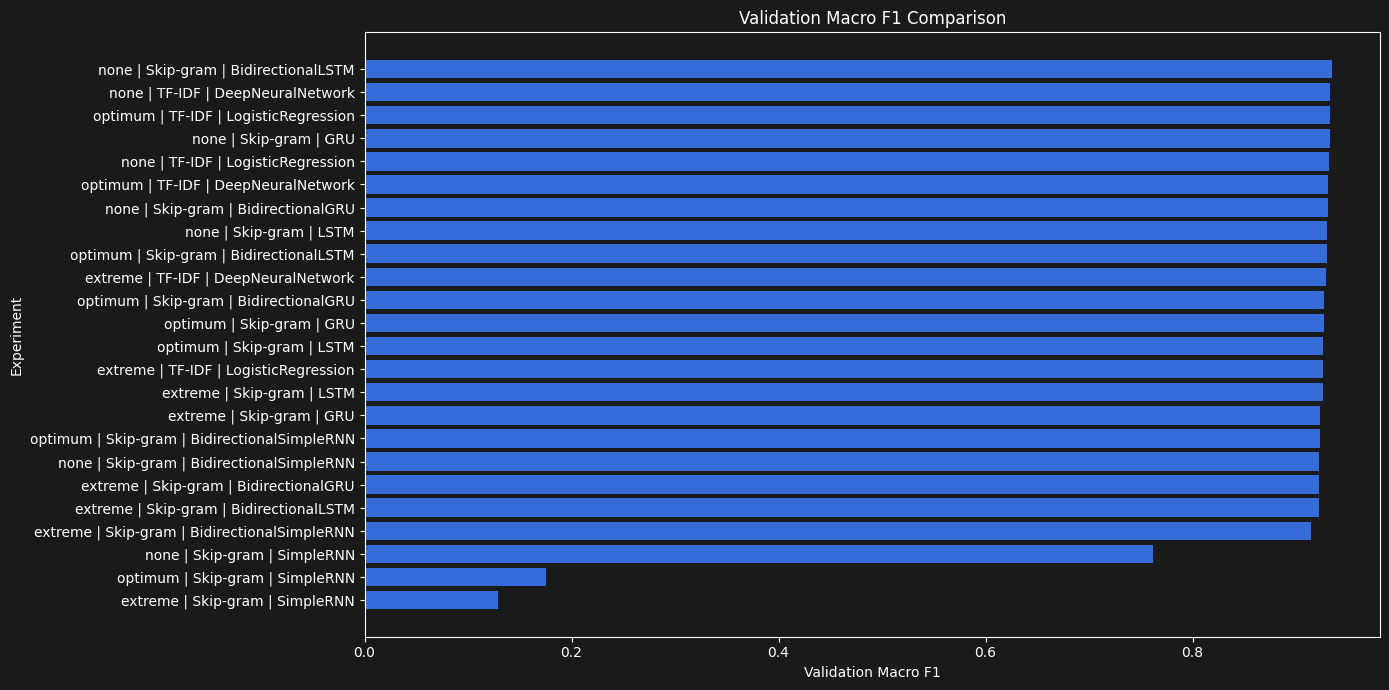

Best validation experiment


,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-24 20:23:23,none,Skip-gram,BidirectionalLSTM,validation,0.94483,0.934417,72.161413,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."


Worst validation experiment


,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
35,2026-04-24 20:24:20,extreme,Skip-gram,SimpleRNN,validation,0.347757,0.129185,33.639481,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."


Best experiment for each preprocessing


,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-24 20:23:23,none,Skip-gram,BidirectionalLSTM,validation,0.944830,0.934417,72.161413,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
2,2026-04-24 20:04:59,optimum,TF-IDF,LogisticRegression,validation,0.943875,0.932534,24.100349,"{""max_features"": 80000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99, ""C"": 4.0}"
12,2026-04-24 20:09:20,extreme,TF-IDF,DeepNeuralNetwork,validation,0.941521,0.928852,89.229115,"{""tfidf"": {""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""hidden_layers"": [512, 256, 128, 64], ""dropout"": 0.35, ""lr"": 0.001, ""weight_decay"": 0.0001, ""batch_size"": 256, ""epochs"": 8, ""patience"": 2}"


In [23]:

validation_results = show_experiment_log("validation")

if not validation_results.empty:
    plt.figure(figsize=(14, 7))
    labels = (
        validation_results["preprocessing"]
        + " | "
        + validation_results["representation"]
        + " | "
        + validation_results["model"]
    )
    plt.barh(labels, validation_results["macro_f1"])
    plt.xlabel("Validation Macro F1")
    plt.ylabel("Experiment")
    plt.title("Validation Macro F1 Comparison")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("Best validation experiment")
    display(validation_results.head(1))

    print("Worst validation experiment")
    display(validation_results.tail(1))

    print("Best experiment for each preprocessing")
    display(
        validation_results
        .sort_values("macro_f1", ascending=False)
        .groupby("preprocessing")
        .head(1)
        .sort_values("macro_f1", ascending=False)
    )



## 12. Final test evaluation

The test set is used only here after validation-based tuning. This section evaluates the best saved artifact for each required combination.



##########################################################################################
TEST | none | TF-IDF | LogisticRegression
Accuracy: 0.90692
Macro F1: 0.90688

Classification Report
                        precision    recall  f1-score   support

              Business       0.93      0.83      0.88      3000
Science and Technology       0.82      0.96      0.88      3000
                Sports       0.95      0.97      0.96      3000
            World News       0.95      0.86      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



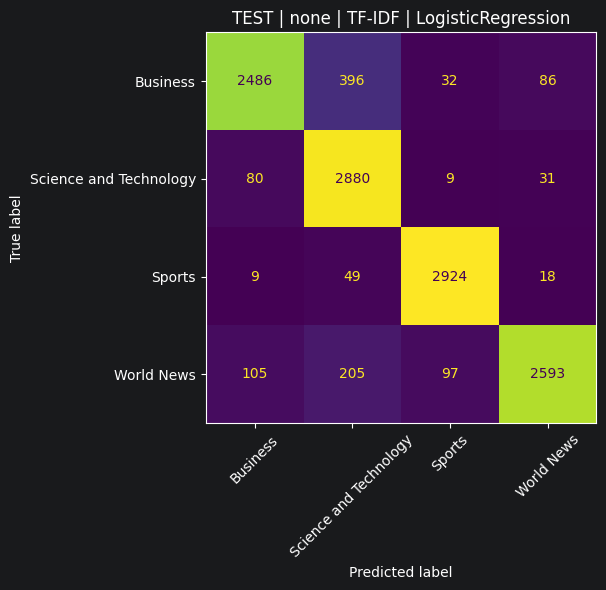


##########################################################################################
TEST | extreme | TF-IDF | LogisticRegression
Accuracy: 0.91258
Macro F1: 0.91244

Classification Report
                        precision    recall  f1-score   support

              Business       0.88      0.88      0.88      3000
Science and Technology       0.89      0.90      0.89      3000
                Sports       0.95      0.98      0.97      3000
            World News       0.93      0.89      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



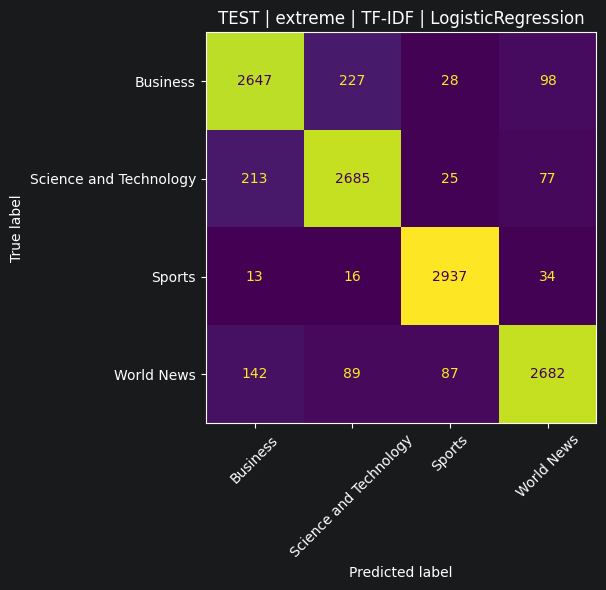


##########################################################################################
TEST | optimum | TF-IDF | LogisticRegression
Accuracy: 0.91442
Macro F1: 0.91422

Classification Report
                        precision    recall  f1-score   support

              Business       0.89      0.88      0.88      3000
Science and Technology       0.89      0.91      0.90      3000
                Sports       0.95      0.98      0.96      3000
            World News       0.93      0.89      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



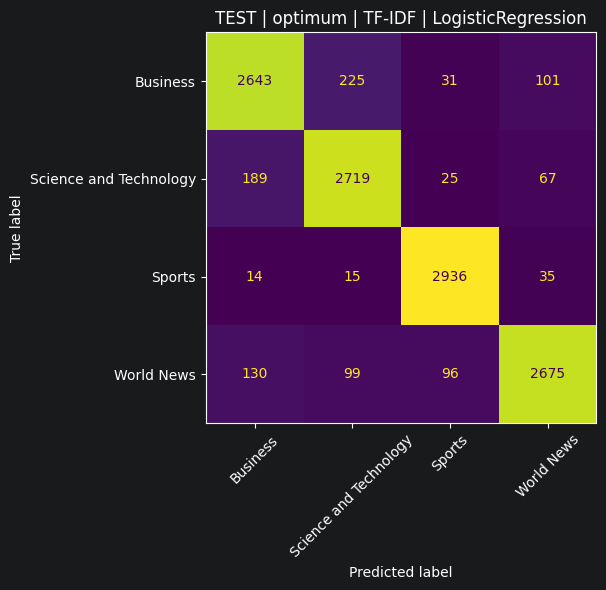


##########################################################################################
TEST | none | TF-IDF | DeepNeuralNetwork
Accuracy: 0.89708
Macro F1: 0.89719

Classification Report
                        precision    recall  f1-score   support

              Business       0.92      0.82      0.87      3000
Science and Technology       0.80      0.95      0.87      3000
                Sports       0.95      0.97      0.96      3000
            World News       0.94      0.85      0.89      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weighted avg       0.90      0.90      0.90     12000



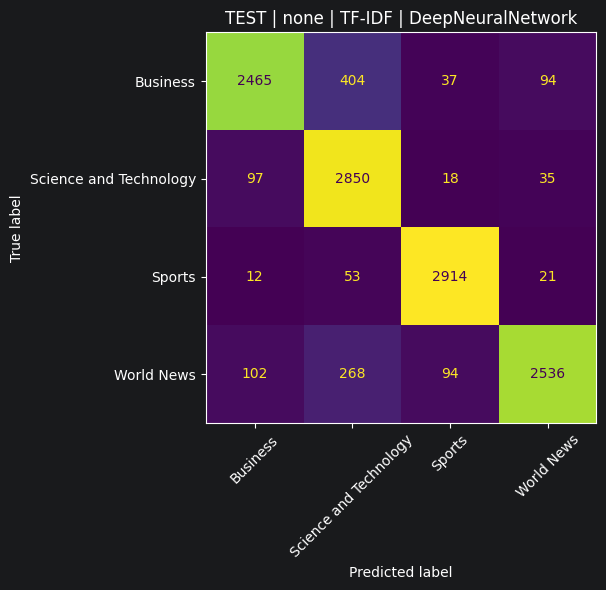


##########################################################################################
TEST | extreme | TF-IDF | DeepNeuralNetwork
Accuracy: 0.90792
Macro F1: 0.90798

Classification Report
                        precision    recall  f1-score   support

              Business       0.87      0.89      0.88      3000
Science and Technology       0.88      0.89      0.89      3000
                Sports       0.96      0.97      0.96      3000
            World News       0.93      0.89      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



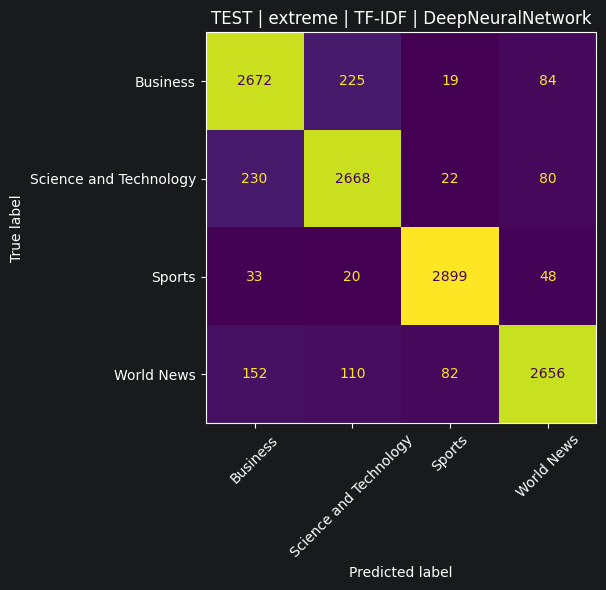


##########################################################################################
TEST | optimum | TF-IDF | DeepNeuralNetwork
Accuracy: 0.90917
Macro F1: 0.90924

Classification Report
                        precision    recall  f1-score   support

              Business       0.85      0.90      0.87      3000
Science and Technology       0.90      0.87      0.89      3000
                Sports       0.96      0.97      0.97      3000
            World News       0.93      0.89      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



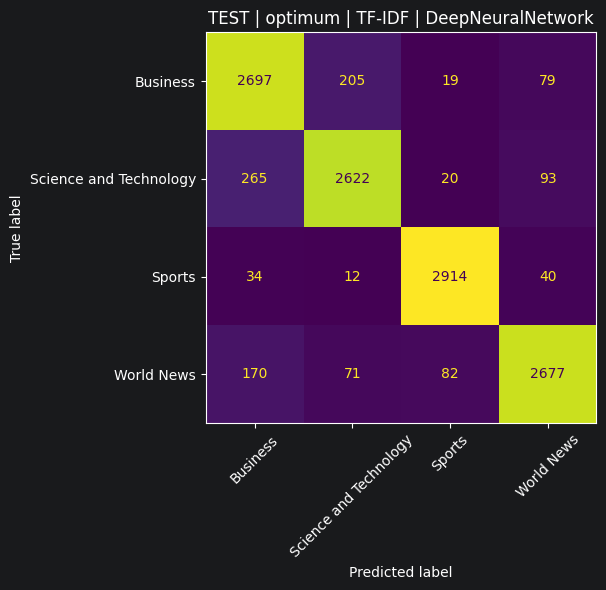


##########################################################################################
TEST | none | Skip-gram | SimpleRNN
Accuracy: 0.78808
Macro F1: 0.78613

Classification Report
                        precision    recall  f1-score   support

              Business       0.78      0.68      0.73      3000
Science and Technology       0.84      0.66      0.74      3000
                Sports       0.89      0.93      0.91      3000
            World News       0.68      0.88      0.77      3000

              accuracy                           0.79     12000
             macro avg       0.80      0.79      0.79     12000
          weighted avg       0.80      0.79      0.79     12000



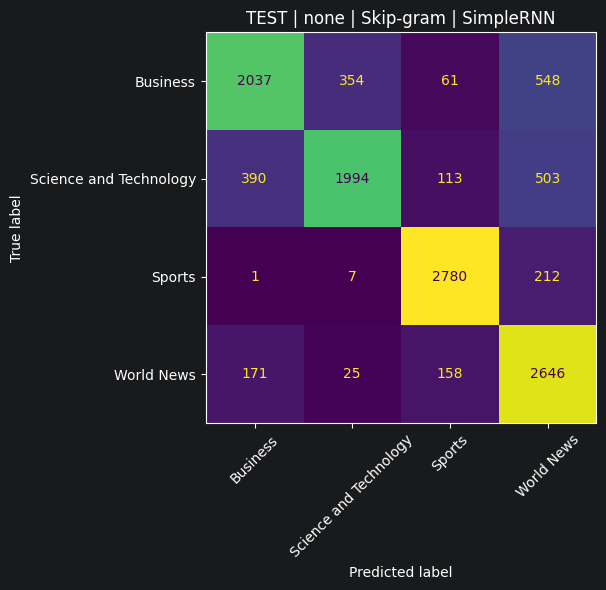


##########################################################################################
TEST | none | Skip-gram | GRU
Accuracy: 0.916
Macro F1: 0.91576

Classification Report
                        precision    recall  f1-score   support

              Business       0.88      0.89      0.89      3000
Science and Technology       0.90      0.89      0.90      3000
                Sports       0.95      0.98      0.97      3000
            World News       0.93      0.90      0.92      3000

              accuracy                           0.92     12000
             macro avg       0.92      0.92      0.92     12000
          weighted avg       0.92      0.92      0.92     12000



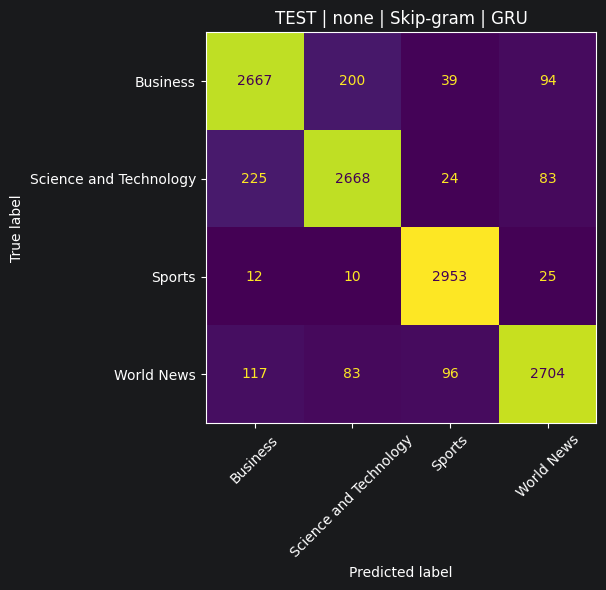


##########################################################################################
TEST | none | Skip-gram | LSTM
Accuracy: 0.90867
Macro F1: 0.90849

Classification Report
                        precision    recall  f1-score   support

              Business       0.87      0.88      0.88      3000
Science and Technology       0.89      0.88      0.88      3000
                Sports       0.95      0.98      0.97      3000
            World News       0.93      0.89      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



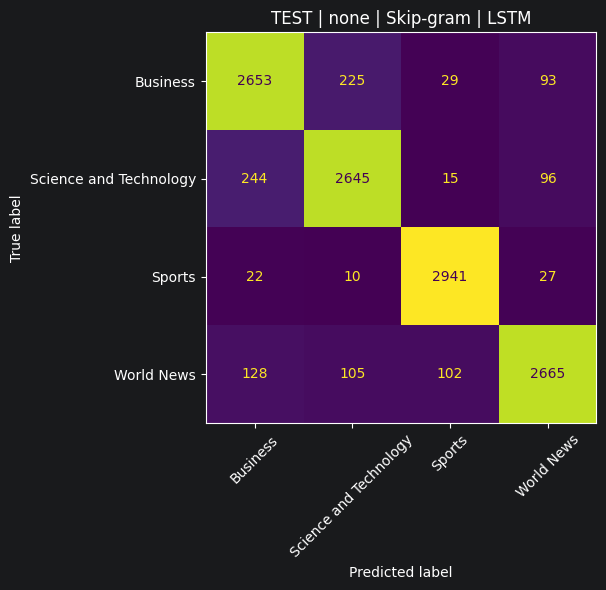


##########################################################################################
TEST | none | Skip-gram | BidirectionalSimpleRNN
Accuracy: 0.9035
Macro F1: 0.9037

Classification Report
                        precision    recall  f1-score   support

              Business       0.85      0.89      0.87      3000
Science and Technology       0.88      0.89      0.88      3000
                Sports       0.95      0.96      0.96      3000
            World News       0.94      0.87      0.90      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weighted avg       0.90      0.90      0.90     12000



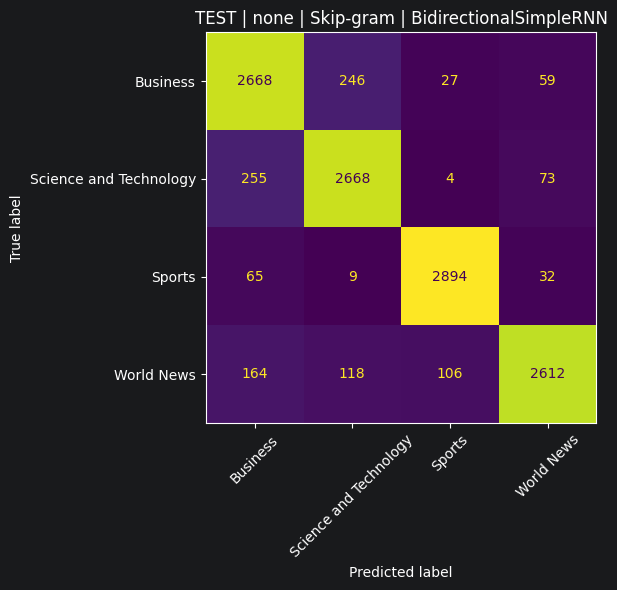


##########################################################################################
TEST | none | Skip-gram | BidirectionalGRU
Accuracy: 0.903
Macro F1: 0.90316

Classification Report
                        precision    recall  f1-score   support

              Business       0.88      0.85      0.87      3000
Science and Technology       0.84      0.91      0.87      3000
                Sports       0.97      0.97      0.97      3000
            World News       0.93      0.89      0.91      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weighted avg       0.90      0.90      0.90     12000



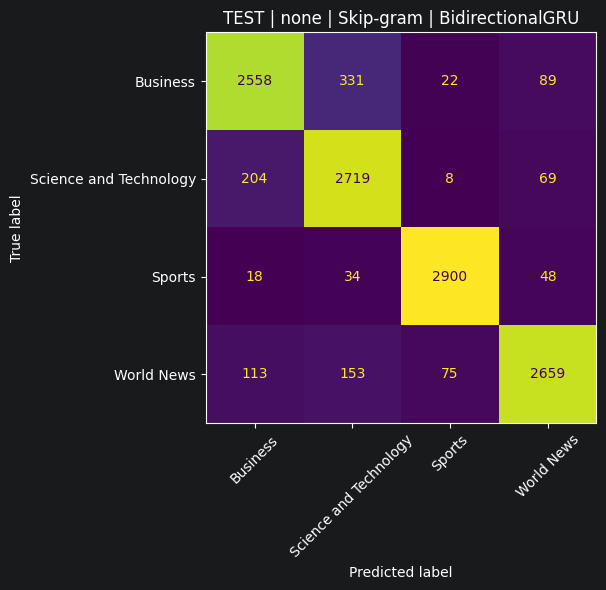


##########################################################################################
TEST | none | Skip-gram | BidirectionalLSTM
Accuracy: 0.91292
Macro F1: 0.9129

Classification Report
                        precision    recall  f1-score   support

              Business       0.88      0.89      0.88      3000
Science and Technology       0.88      0.90      0.89      3000
                Sports       0.96      0.98      0.97      3000
            World News       0.93      0.89      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



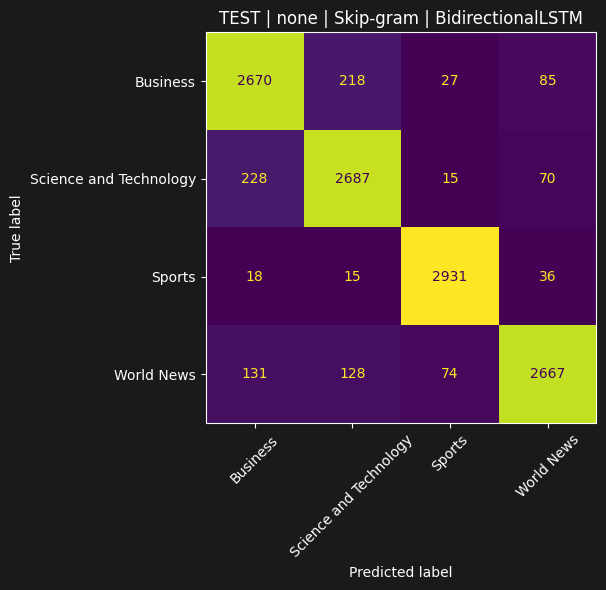


##########################################################################################
TEST | extreme | Skip-gram | SimpleRNN
Accuracy: 0.24983
Macro F1: 0.09995

Classification Report
                        precision    recall  f1-score   support

              Business       0.00      0.00      0.00      3000
Science and Technology       0.25      1.00      0.40      3000
                Sports       0.00      0.00      0.00      3000
            World News       0.00      0.00      0.00      3000

              accuracy                           0.25     12000
             macro avg       0.06      0.25      0.10     12000
          weighted avg       0.06      0.25      0.10     12000



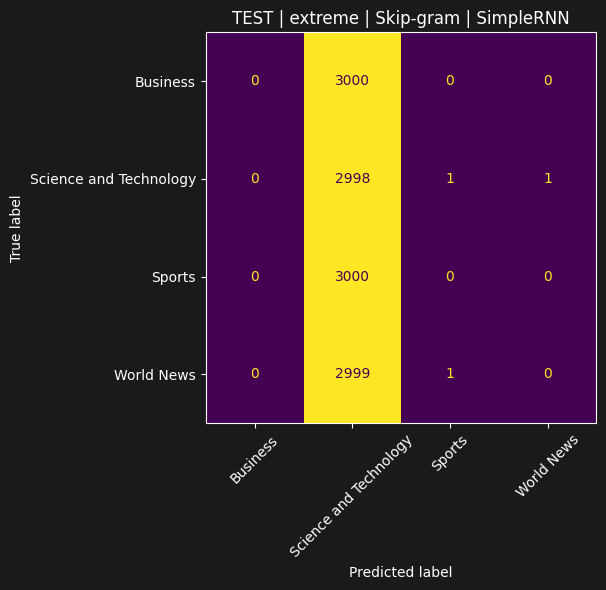


##########################################################################################
TEST | extreme | Skip-gram | GRU
Accuracy: 0.90783
Macro F1: 0.90767

Classification Report
                        precision    recall  f1-score   support

              Business       0.88      0.87      0.87      3000
Science and Technology       0.87      0.91      0.89      3000
                Sports       0.95      0.98      0.97      3000
            World News       0.94      0.87      0.90      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



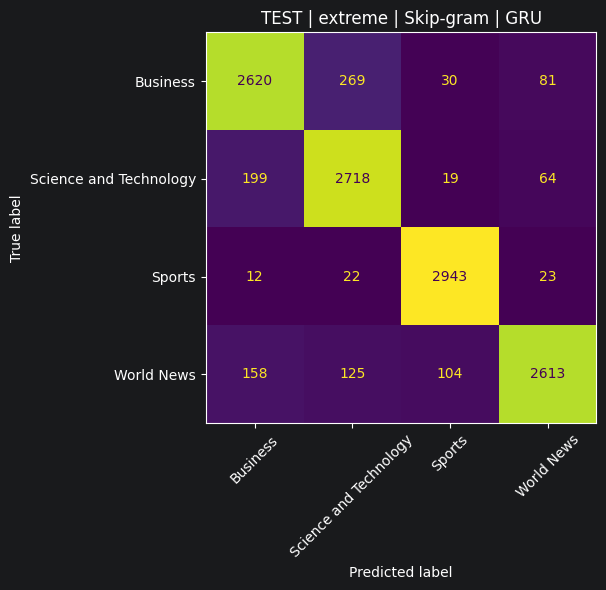


##########################################################################################
TEST | extreme | Skip-gram | LSTM
Accuracy: 0.905
Macro F1: 0.9049

Classification Report
                        precision    recall  f1-score   support

              Business       0.88      0.86      0.87      3000
Science and Technology       0.87      0.89      0.88      3000
                Sports       0.96      0.97      0.97      3000
            World News       0.91      0.89      0.90      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.90     12000
          weighted avg       0.91      0.91      0.90     12000



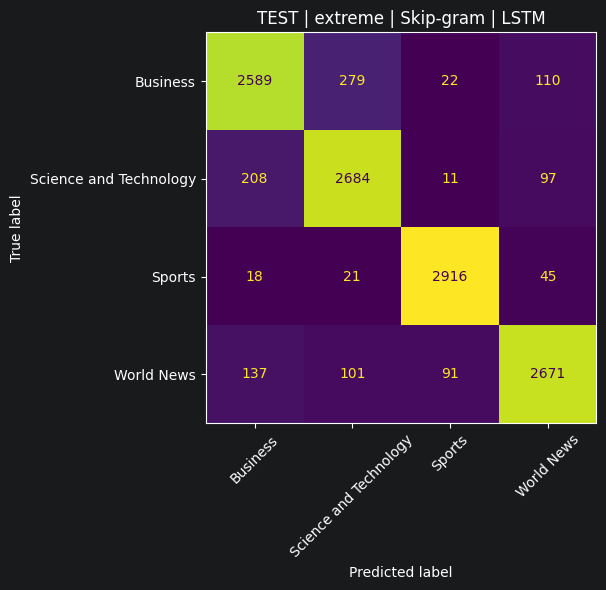


##########################################################################################
TEST | extreme | Skip-gram | BidirectionalSimpleRNN
Accuracy: 0.90542
Macro F1: 0.90524

Classification Report
                        precision    recall  f1-score   support

              Business       0.86      0.88      0.87      3000
Science and Technology       0.89      0.87      0.88      3000
                Sports       0.95      0.98      0.96      3000
            World News       0.92      0.89      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



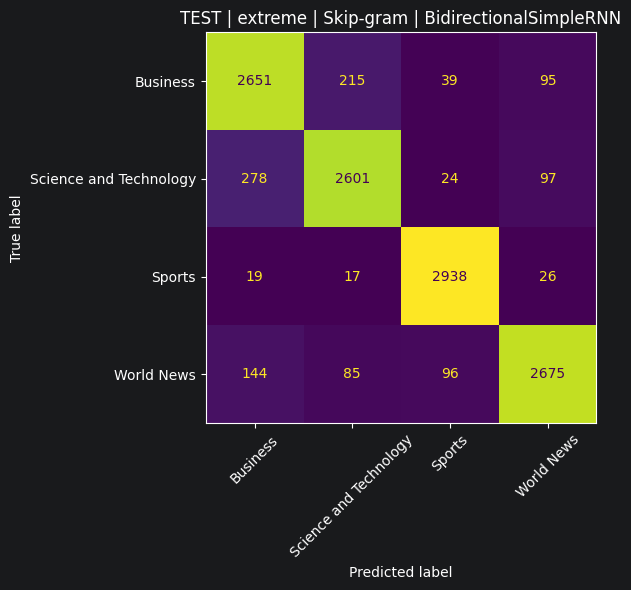


##########################################################################################
TEST | extreme | Skip-gram | BidirectionalGRU
Accuracy: 0.90675
Macro F1: 0.90681

Classification Report
                        precision    recall  f1-score   support

              Business       0.86      0.89      0.87      3000
Science and Technology       0.88      0.88      0.88      3000
                Sports       0.96      0.97      0.97      3000
            World News       0.94      0.88      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



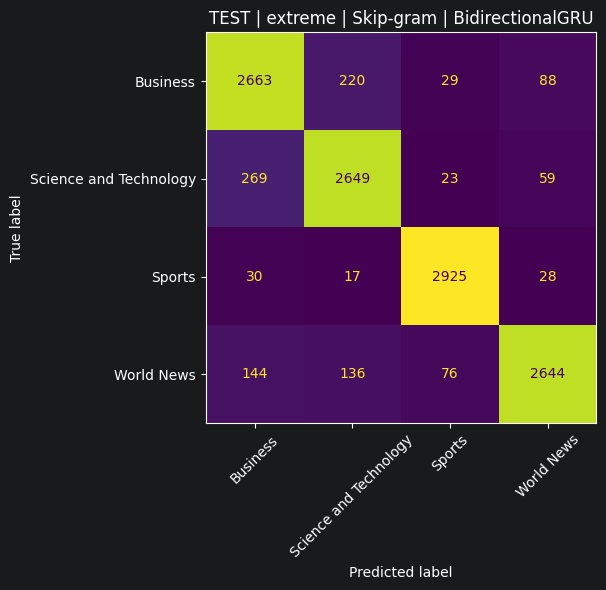


##########################################################################################
TEST | extreme | Skip-gram | BidirectionalLSTM
Accuracy: 0.907
Macro F1: 0.90712

Classification Report
                        precision    recall  f1-score   support

              Business       0.84      0.90      0.87      3000
Science and Technology       0.89      0.87      0.88      3000
                Sports       0.96      0.97      0.97      3000
            World News       0.95      0.88      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



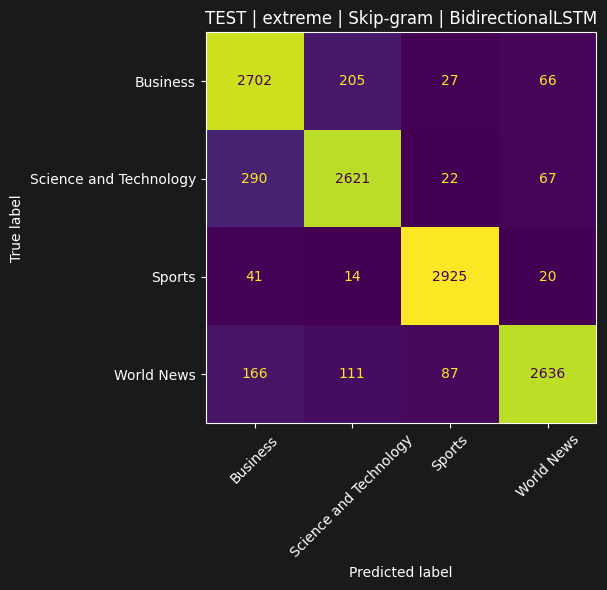


##########################################################################################
TEST | optimum | Skip-gram | SimpleRNN
Accuracy: 0.27467
Macro F1: 0.14739

Classification Report
                        precision    recall  f1-score   support

              Business       0.00      0.00      0.00      3000
Science and Technology       0.76      0.10      0.17      3000
                Sports       0.26      1.00      0.41      3000
            World News       0.61      0.00      0.01      3000

              accuracy                           0.27     12000
             macro avg       0.41      0.27      0.15     12000
          weighted avg       0.41      0.27      0.15     12000



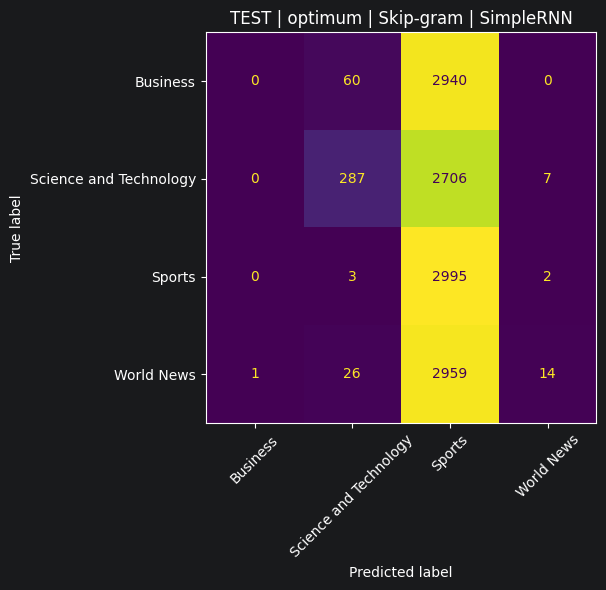


##########################################################################################
TEST | optimum | Skip-gram | GRU
Accuracy: 0.90417
Macro F1: 0.90424

Classification Report
                        precision    recall  f1-score   support

              Business       0.86      0.88      0.87      3000
Science and Technology       0.88      0.88      0.88      3000
                Sports       0.96      0.96      0.96      3000
            World News       0.91      0.89      0.90      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weighted avg       0.90      0.90      0.90     12000



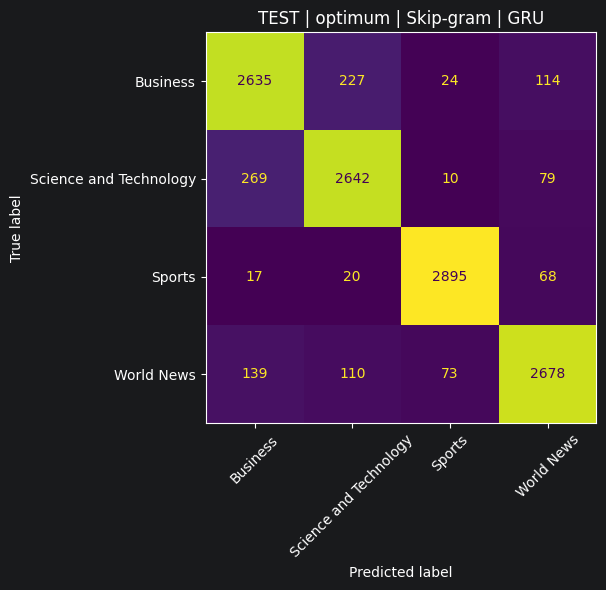


##########################################################################################
TEST | optimum | Skip-gram | LSTM
Accuracy: 0.90425
Macro F1: 0.90413

Classification Report
                        precision    recall  f1-score   support

              Business       0.86      0.88      0.87      3000
Science and Technology       0.89      0.86      0.88      3000
                Sports       0.96      0.98      0.97      3000
            World News       0.91      0.90      0.90      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weighted avg       0.90      0.90      0.90     12000



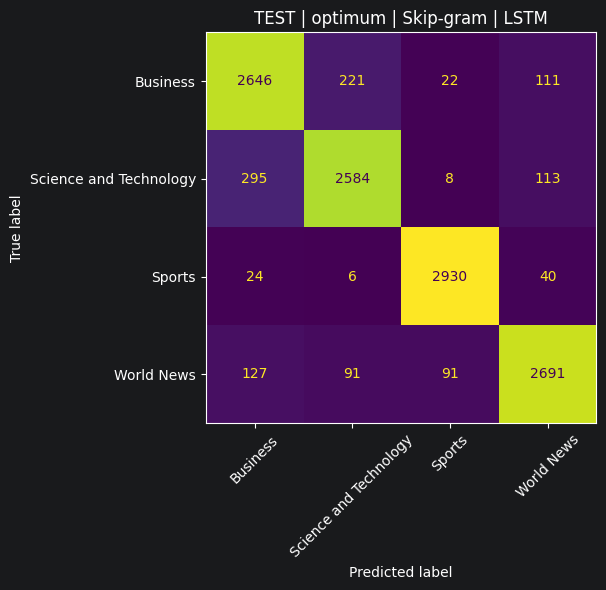


##########################################################################################
TEST | optimum | Skip-gram | BidirectionalSimpleRNN
Accuracy: 0.90583
Macro F1: 0.90561

Classification Report
                        precision    recall  f1-score   support

              Business       0.89      0.85      0.87      3000
Science and Technology       0.86      0.91      0.89      3000
                Sports       0.96      0.98      0.97      3000
            World News       0.92      0.89      0.90      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



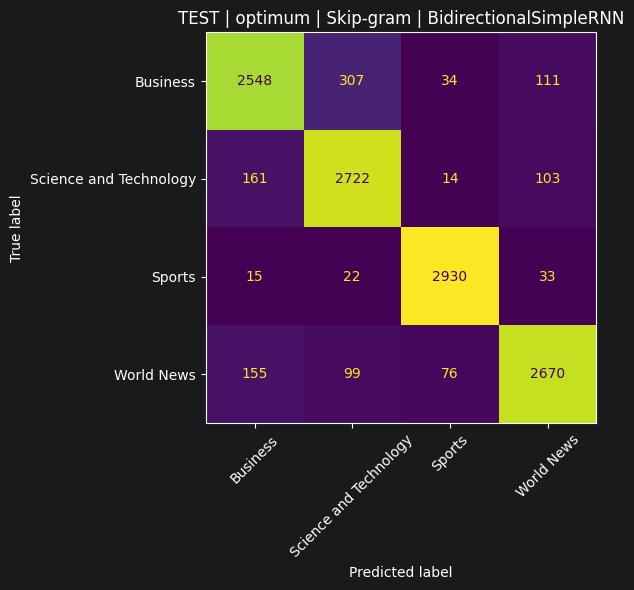


##########################################################################################
TEST | optimum | Skip-gram | BidirectionalGRU
Accuracy: 0.90342
Macro F1: 0.90363

Classification Report
                        precision    recall  f1-score   support

              Business       0.83      0.91      0.87      3000
Science and Technology       0.89      0.86      0.88      3000
                Sports       0.96      0.98      0.97      3000
            World News       0.94      0.87      0.90      3000

              accuracy                           0.90     12000
             macro avg       0.91      0.90      0.90     12000
          weighted avg       0.91      0.90      0.90     12000



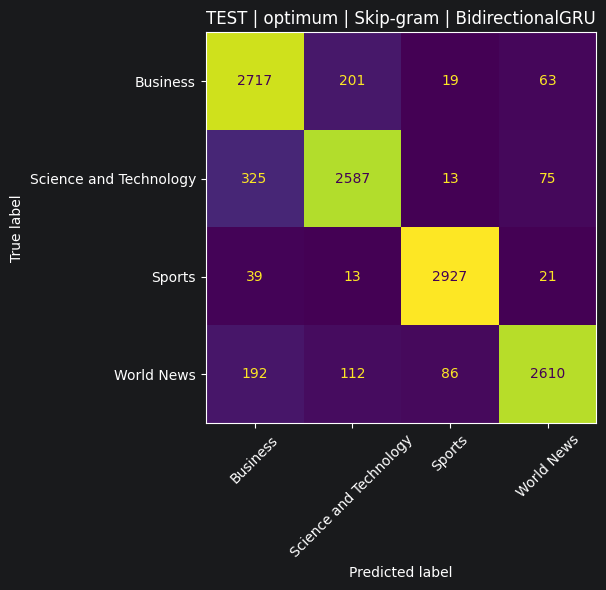


##########################################################################################
TEST | optimum | Skip-gram | BidirectionalLSTM
Accuracy: 0.89883
Macro F1: 0.89889

Classification Report
                        precision    recall  f1-score   support

              Business       0.85      0.88      0.86      3000
Science and Technology       0.87      0.86      0.87      3000
                Sports       0.96      0.97      0.97      3000
            World News       0.92      0.88      0.90      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weighted avg       0.90      0.90      0.90     12000



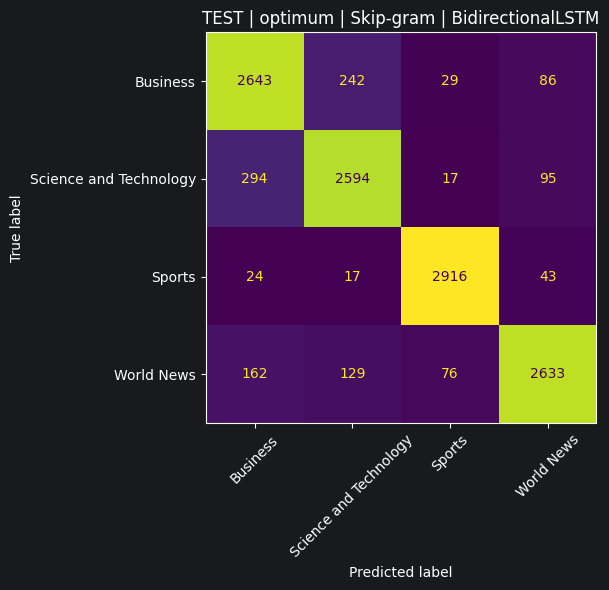

,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-24 20:55:04,none,Skip-gram,GRU,test,0.916000,0.915756,NaN,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
1,2026-04-24 20:54:50,optimum,TF-IDF,LogisticRegression,test,0.914417,0.914222,NaN,"{""max_features"": 80000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99, ""C"": 4.0}"
2,2026-04-24 20:55:09,none,Skip-gram,BidirectionalLSTM,test,0.912917,0.912899,NaN,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
3,2026-04-24 20:54:49,extreme,TF-IDF,LogisticRegression,test,0.912583,0.912435,NaN,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
4,2026-04-24 20:55:02,optimum,TF-IDF,DeepNeuralNetwork,test,0.909167,0.909240,NaN,"{""tfidf"": {""max_features"": 60000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99}, ""hidden_layers"": [1024, 512, 256, 128], ""dropout"": 0.4, ""lr"": 0.0007, ""weight_decay"": 0.0002, ""batch_size"": 192, ""epochs"": 10, ""patience"": 3}"
5,2026-04-24 20:55:05,none,Skip-gram,LSTM,test,0.908667,0.908492,NaN,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
6,2026-04-24 20:54:57,extreme,TF-IDF,DeepNeuralNetwork,test,0.907917,0.907981,NaN,"{""tfidf"": {""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""hidden_layers"": [512, 256, 128, 64], ""dropout"": 0.35, ""lr"": 0.001, ""weight_decay"": 0.0001, ""batch_size"": 256, ""epochs"": 8, ""patience"": 2}"
7,2026-04-24 20:55:10,extreme,Skip-gram,GRU,test,0.907833,0.907673,NaN,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
8,2026-04-24 20:55:14,extreme,Skip-gram,BidirectionalLSTM,test,0.907000,0.907123,NaN,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
9,2026-04-24 20:54:48,none,TF-IDF,LogisticRegression,test,0.906917,0.906878,NaN,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"


Saved log to: logs\experiment_log_pytorch.csv


,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-24 20:02:56,none,TF-IDF,LogisticRegression,validation,0.932803,0.921611,24.646307,"{""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 1.0}"
1,2026-04-24 20:03:19,none,TF-IDF,LogisticRegression,validation,0.942094,0.931430,23.372463,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
2,2026-04-24 20:03:33,extreme,TF-IDF,LogisticRegression,validation,0.930449,0.918864,13.545148,"{""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.95, ""C"": 1.0}"
3,2026-04-24 20:03:48,extreme,TF-IDF,LogisticRegression,validation,0.937512,0.926068,15.677610,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
4,2026-04-24 20:04:10,optimum,TF-IDF,LogisticRegression,validation,0.938021,0.926522,21.544559,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
5,2026-04-24 20:04:35,optimum,TF-IDF,LogisticRegression,validation,0.942857,0.931485,24.465277,"{""max_features"": 60000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 4.0}"
6,2026-04-24 20:04:59,optimum,TF-IDF,LogisticRegression,validation,0.943875,0.932534,24.100349,"{""max_features"": 80000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99, ""C"": 4.0}"
7,2026-04-24 20:05:34,optimum,TF-IDF,LogisticRegression,validation,0.941839,0.930339,35.217938,"{""max_features"": 70000, ""ngram_range"": [1, 3], ""min_df"": 2, ""max_df"": 0.99, ""C"": 3.0}"
8,2026-04-24 20:07:38,none,TF-IDF,DeepNeuralNetwork,validation,0.944384,0.932757,102.959434,"{""tfidf"": {""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""hidden_layers"": [512, 256, 128, 64], ""dropout"": 0.35, ""lr"": 0.001, ""weight_decay"": 0.0001, ""batch_size"": 256, ""epochs"": 8, ""patience"": 2}"
9,2026-04-24 20:09:20,extreme,TF-IDF,DeepNeuralNetwork,validation,0.941521,0.928852,89.229115,"{""tfidf"": {""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""hidden_layers"": [512, 256, 128, 64], ""dropout"": 0.35, ""lr"": 0.001, ""weight_decay"": 0.0001, ""batch_size"": 256, ""epochs"": 8, ""patience"": 2}"


In [24]:

def evaluate_tfidf_ml_on_test(artifact):
    preprocess_name = artifact["preprocessing"]
    test_texts = preprocessed_test[preprocess_name][TEXT_COLUMN].fillna("").tolist()

    X_test = artifact["vectorizer"].transform(test_texts)
    y_pred = artifact["model"].predict(X_test)

    return y_pred

def evaluate_tfidf_dnn_on_test(artifact):
    preprocess_name = artifact["preprocessing"]
    test_texts = preprocessed_test[preprocess_name][TEXT_COLUMN].fillna("").tolist()

    X_test = artifact["vectorizer"].transform(test_texts)
    batch_size = artifact["params"]["batch_size"]
    y_pred = predict_tfidf_dnn(artifact["model"], X_test, batch_size=batch_size)

    return y_pred

def evaluate_skipgram_sequence_on_test(artifact):
    preprocess_name = artifact["preprocessing"]
    seq_config = artifact["seq_config"]
    vocab = artifact["vocab"]

    test_tokens = get_tokens_for_split(preprocess_name, indices=None, split="test")
    X_test_seq = token_lists_to_padded_sequences(test_tokens, vocab, seq_config["max_len"])

    test_dataset = SequenceTextDataset(X_test_seq, y_test)
    test_loader = DataLoader(
        test_dataset,
        batch_size=seq_config["batch_size"],
        shuffle=False,
        num_workers=0
    )

    y_true_test, y_pred_test = predict_sequence_model(artifact["model"], test_loader)
    return y_pred_test

def evaluate_artifact_on_test(key, artifact, show_matrix=True):
    preprocess_name, representation, model_name = key

    if artifact["kind"] == "tfidf_ml":
        y_pred = evaluate_tfidf_ml_on_test(artifact)
    elif artifact["kind"] == "tfidf_dnn":
        y_pred = evaluate_tfidf_dnn_on_test(artifact)
    elif artifact["kind"] == "skipgram_sequence":
        y_pred = evaluate_skipgram_sequence_on_test(artifact)
    else:
        raise ValueError("Unknown artifact kind.")

    title = f"TEST | {preprocess_name} | {representation} | {model_name}"
    metrics = print_evaluation(title, y_test, y_pred, show_matrix=show_matrix)

    add_experiment_log(
        preprocess_name=preprocess_name,
        representation=representation,
        model_name=model_name,
        split_name="test",
        y_true=y_test,
        y_pred=y_pred,
        params=artifact["params"],
        train_seconds=None
    )

    return metrics, y_pred

test_predictions = {}

for key, artifact in BEST_ARTIFACTS.items():
    print("\n" + "#" * 90)
    metrics, y_pred = evaluate_artifact_on_test(key, artifact, show_matrix=True)
    test_predictions[key] = y_pred

test_results = show_experiment_log("test")
save_log()


## 13. Final comparison: best and worst models/preprocessing techniques

,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-24 20:55:04,none,Skip-gram,GRU,test,0.916000,0.915756,NaN,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
1,2026-04-24 20:54:50,optimum,TF-IDF,LogisticRegression,test,0.914417,0.914222,NaN,"{""max_features"": 80000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99, ""C"": 4.0}"
2,2026-04-24 20:55:09,none,Skip-gram,BidirectionalLSTM,test,0.912917,0.912899,NaN,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
3,2026-04-24 20:54:49,extreme,TF-IDF,LogisticRegression,test,0.912583,0.912435,NaN,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"
4,2026-04-24 20:55:02,optimum,TF-IDF,DeepNeuralNetwork,test,0.909167,0.909240,NaN,"{""tfidf"": {""max_features"": 60000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99}, ""hidden_layers"": [1024, 512, 256, 128], ""dropout"": 0.4, ""lr"": 0.0007, ""weight_decay"": 0.0002, ""batch_size"": 192, ""epochs"": 10, ""patience"": 3}"
5,2026-04-24 20:55:05,none,Skip-gram,LSTM,test,0.908667,0.908492,NaN,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
6,2026-04-24 20:54:57,extreme,TF-IDF,DeepNeuralNetwork,test,0.907917,0.907981,NaN,"{""tfidf"": {""max_features"": 30000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98}, ""hidden_layers"": [512, 256, 128, 64], ""dropout"": 0.35, ""lr"": 0.001, ""weight_decay"": 0.0001, ""batch_size"": 256, ""epochs"": 8, ""patience"": 2}"
7,2026-04-24 20:55:10,extreme,Skip-gram,GRU,test,0.907833,0.907673,NaN,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
8,2026-04-24 20:55:14,extreme,Skip-gram,BidirectionalLSTM,test,0.907000,0.907123,NaN,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."
9,2026-04-24 20:54:48,none,TF-IDF,LogisticRegression,test,0.906917,0.906878,NaN,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"


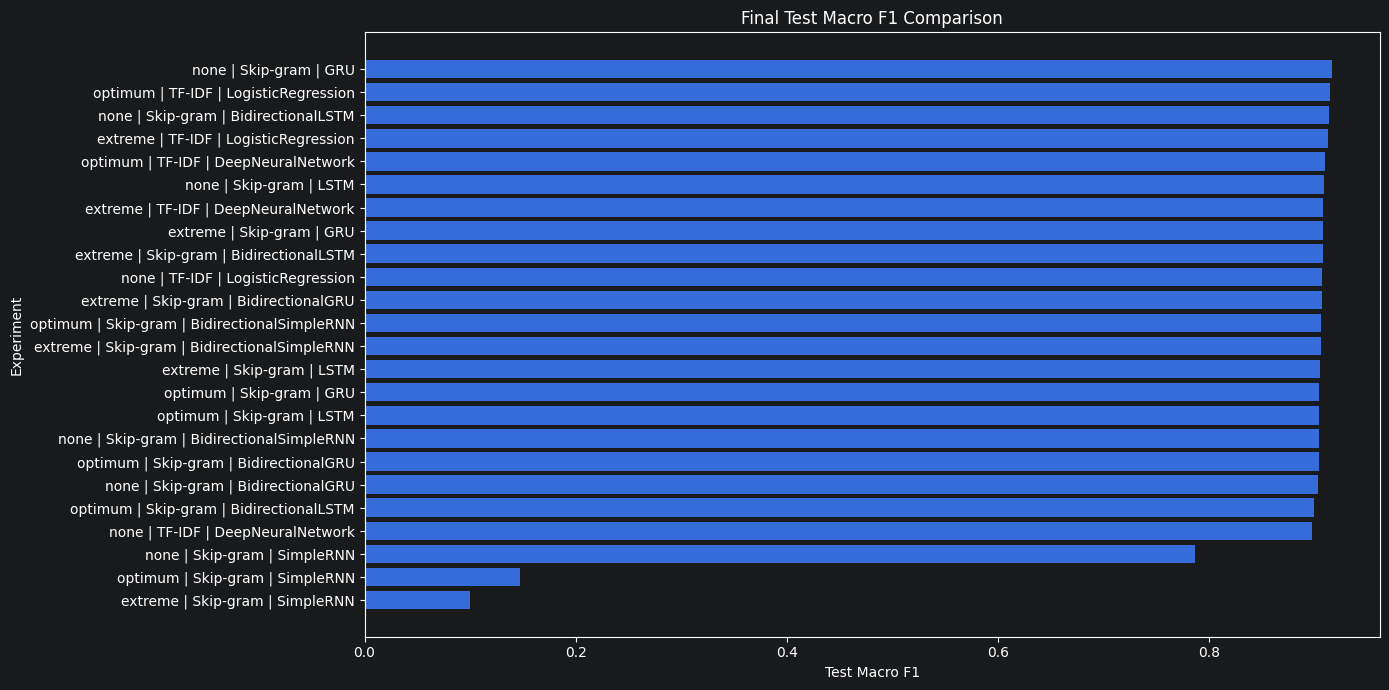

Best final test model


,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
0,2026-04-24 20:55:04,none,Skip-gram,GRU,test,0.916,0.915756,NaN,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."


Worst final test model


,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
23,2026-04-24 20:55:10,extreme,Skip-gram,SimpleRNN,test,0.249833,0.099953,NaN,"{""word2vec_vector_size"": 100, ""word2vec_window"": 5, ""word2vec_min_count"": 2, ""word2vec_epochs"": 8, ""max_words"": 35000, ""max_len"": 60, ""hidden_size"": 128, ""num_layers"": 1, ""dropout"": 0.35, ""dense_size"": 96, ""batch_size"": 256, ""lr"": 0.001, ""weight_decay"": 0.0001, ""epochs"": 8, ""patience"": 2, ""model..."


Best test result by preprocessing technique


...

Optimum best


,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
1,2026-04-24 20:54:50,optimum,TF-IDF,LogisticRegression,test,0.914417,0.914222,NaN,"{""max_features"": 80000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.99, ""C"": 4.0}"


Extreme best


,time,preprocessing,representation,model,split,accuracy,macro_f1,train_seconds,params
3,2026-04-24 20:54:49,extreme,TF-IDF,LogisticRegression,test,0.912583,0.912435,NaN,"{""max_features"": 50000, ""ngram_range"": [1, 2], ""min_df"": 2, ""max_df"": 0.98, ""C"": 2.0}"


Optimum best macro F1 - Extreme best macro F1 = 0.00179


In [25]:

test_results = pd.DataFrame(EXPERIMENT_LOG)
test_results = test_results[test_results["split"] == "test"].copy()

if not test_results.empty:
    test_results = test_results.sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
    display(test_results)

    plt.figure(figsize=(14, 7))
    labels = (
        test_results["preprocessing"]
        + " | "
        + test_results["representation"]
        + " | "
        + test_results["model"]
    )
    plt.barh(labels, test_results["macro_f1"])
    plt.xlabel("Test Macro F1")
    plt.ylabel("Experiment")
    plt.title("Final Test Macro F1 Comparison")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("Best final test model")
    display(test_results.head(1))

    print("Worst final test model")
    display(test_results.tail(1))

    print("Best test result by preprocessing technique")
    display(
        test_results
        .sort_values("macro_f1", ascending=False)
        .groupby("preprocessing")
        .head(1)
        .sort_values("macro_f1", ascending=False)
    )

    optimum_best = test_results[test_results["preprocessing"] == "optimum"].head(1)
    extreme_best = test_results[test_results["preprocessing"] == "extreme"].head(1)

    print("Optimum best")
    display(optimum_best)

    print("Extreme best")
    display(extreme_best)

    if not optimum_best.empty and not extreme_best.empty:
        difference = optimum_best.iloc[0]["macro_f1"] - extreme_best.iloc[0]["macro_f1"]
        print(f"Optimum best macro F1 - Extreme best macro F1 = {difference:.5f}")



## 14. Notes for the report

Use the generated validation and test result tables to write the report.

Recommended points to explain:

1. **No preprocessing** keeps the raw text, including HTML noise. It is a baseline.
2. **Extreme preprocessing** removes stopwords and stems words. This can reduce noise but may also remove useful classification clues.
3. **Optimum preprocessing** removes HTML, repeated boilerplate, and obvious noise while preserving meaningful words, numbers, hyphenated tokens, place names, organization names, team names, and technology terms.
4. TF-IDF + Logistic Regression is usually strong for news classification because word and n-gram signals are highly informative.
5. Neural models may improve with GPU, more epochs, and stronger hyperparameter tuning, but they can also overfit if the dataset is not cleaned well.
6. The test set was used only after validation tuning.
